# 2D Sketch to 3D Point Cloud - Advanced Encoder

Model for converting 2D sketches to 3D point clouds.

**Improvements over baseline:**
- Better encoder (ResNet-based with attention)
- Improved decoder (FoldingNet with refinement)
- Multiple loss functions (Chamfer + EMD + repulsion)
- Strong data augmentation
- Training utilities and visualization

## 1. Setup and Imports

In [1]:
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:3


## 2. Configuration

In [ ]:
class Config:
    # Data
    data_root = "../../data/ShapeNet"
    category_id = "02691156"  # Airplane
    
    # Model
    latent_dim = 512
    num_points = 2048
    
    # Training
    batch_size = 16
    num_epochs = 150
    learning_rate = 1e-4
    weight_decay = 1e-5
    
    # Loss weights
    chamfer_weight = 1.0
    repulsion_weight = 0.01
    
    # Scheduler
    step_size = 30
    gamma = 0.5
    
    # Checkpointing
    save_dir = "checkpoints"
    save_every = 10
    
    # Visualization
    viz_every = 5
    
config = Config()
os.makedirs(config.save_dir, exist_ok=True)

## 3. Dataset with Strong Augmentation

In [ ]:
class SketchPointDataset(Dataset):
    """Enhanced dataset with strong data augmentation"""
    
    def __init__(self, root, cat_id="02691156", train=True):
        self.train = train
        
        # Load sketch paths
        self.sketch_paths = sorted(glob.glob(os.path.join(root, "2d", cat_id, "*.png")))
        npy_list = glob.glob(os.path.join(root, "npy", cat_id, "*.npy"))
        
        self.npy_map = {os.path.splitext(os.path.basename(p))[0]: p for p in npy_list}
        
        if len(self.sketch_paths) == 0:
            raise RuntimeError(f"No sketches found in {root}")
        
        print(f"Loaded {len(self.sketch_paths)} sketches")
        
        # Augmentation for training
        if train:
            self.tf = transforms.Compose([
                transforms.Resize((28, 28)),  # Slightly larger for better crops
                transforms.RandomRotation(15),
                transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                transforms.RandomResizedCrop(28, scale=(0.8, 1.0)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),  # Random occlusion
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Resize((28, 28)),
                transforms.ToTensor(),
            ])
    
    def __len__(self):
        return len(self.sketch_paths)
    
    def normalize_pc(self, pts):
        pts = pts - pts.mean(0)
        scale = torch.norm(pts, dim=1).max()
        pts = pts / (scale + 1e-8)
        return pts
    
    def __getitem__(self, idx):
        img_path = self.sketch_paths[idx]
        file_id = os.path.basename(img_path).split("_")[0]
        
        # Load and augment image
        img = Image.open(img_path).convert("RGB")
        img = self.tf(img)
        
        # Load and normalize point cloud
        pts = torch.from_numpy(np.load(self.npy_map[file_id])).float()
        pts = self.normalize_pc(pts)
        
        # Random point sampling during training
        if self.train and pts.shape[0] > config.num_points:
            indices = torch.randperm(pts.shape[0])[:config.num_points]
            pts = pts[indices]
        
        return img, pts

## 4. Advanced Encoder with Attention

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.attention = ChannelAttention(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.attention(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class AdvancedSketchEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Residual blocks
        self.layer1 = self._make_layer(64, 128, stride=2)
        self.layer2 = self._make_layer(128, 256, stride=2)
        self.layer3 = self._make_layer(256, 512, stride=2)
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, latent_dim)
        )
    
    def _make_layer(self, in_channels, out_channels, stride):
        return nn.Sequential(
            ResidualBlock(in_channels, out_channels, stride),
            ResidualBlock(out_channels, out_channels, 1)
        )
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        # Combine avg and max pooling
        avg_pool = self.global_avg_pool(x).view(x.size(0), -1)
        max_pool = self.global_max_pool(x).view(x.size(0), -1)
        x = torch.cat([avg_pool, max_pool], dim=1)
        
        x = self.fc(x)
        return x

## 5. Improved FoldingNet Decoder

In [ ]:
class FoldingDecoder(nn.Module):
    def __init__(self, latent_dim=512, num_points=2048):
        super().__init__()
        self.num_points = num_points
        
        # First folding layer (2D grid -> 3D)
        self.fold1 = nn.Sequential(
            nn.Linear(latent_dim + 2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 3)
        )
        
        # Second folding layer (refinement)
        self.fold2 = nn.Sequential(
            nn.Linear(latent_dim + 3, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 3)
        )
        
        # 2D grid
        grid = self._create_grid(num_points)
        self.register_buffer("grid", grid)
    
    def _create_grid(self, num_points):
        grid_size = int(np.sqrt(num_points))
        x = np.linspace(-1, 1, grid_size)
        y = np.linspace(-1, 1, grid_size)
        xx, yy = np.meshgrid(x, y)
        grid = np.stack([xx, yy], axis=-1).reshape(-1, 2)
        
        # If not perfect square, sample additional points
        if grid.shape[0] < num_points:
            extra = num_points - grid.shape[0]
            extra_points = np.random.uniform(-1, 1, (extra, 2))
            grid = np.concatenate([grid, extra_points], axis=0)
        elif grid.shape[0] > num_points:
            grid = grid[:num_points]
        
        return torch.from_numpy(grid).float()
    
    def forward(self, z):
        B = z.shape[0]
        
        # Expand grid and latent code
        grid = self.grid.unsqueeze(0).repeat(B, 1, 1)  # [B, N, 2]
        z_expanded = z.unsqueeze(1).repeat(1, self.num_points, 1)  # [B, N, latent]
        
        # First folding (2D -> 3D)
        x1 = torch.cat([grid, z_expanded], dim=-1)
        fold1_out = self.fold1(x1)  # [B, N, 3]
        
        # Second folding (refinement)
        x2 = torch.cat([fold1_out, z_expanded], dim=-1)
        fold2_out = self.fold2(x2)  # [B, N, 3]
        
        return fold2_out

## 6. Complete Model

In [ ]:
class Sketch2Point(nn.Module):
    def __init__(self, latent_dim=512, num_points=2048):
        super().__init__()
        self.encoder = AdvancedSketchEncoder(in_channels=3, latent_dim=latent_dim)
        self.decoder = FoldingDecoder(latent_dim=latent_dim, num_points=num_points)
    
    def forward(self, x):
        z = self.encoder(x)
        points = self.decoder(z)
        return points
    
    def encode(self, x):
        """Get latent code only"""
        return self.encoder(x)


# Create model
model = Sketch2Point(latent_dim=config.latent_dim, num_points=config.num_points)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model created!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model created!
Total parameters: 12,950,598
Trainable parameters: 12,950,598


## 7. Advanced Loss Functions

In [ ]:
def chamfer_distance(pred, gt):
    B, N, _ = pred.shape
    _, M, _ = gt.shape
    
    # Compute pairwise distances [B, N, M]
    dist = torch.cdist(pred, gt)
    
    # Forward: pred -> gt
    min_dist_pred_to_gt = dist.min(dim=2)[0]  # [B, N]
    
    # Backward: gt -> pred
    min_dist_gt_to_pred = dist.min(dim=1)[0]  # [B, M]
    
    # Average across batch
    cd = min_dist_pred_to_gt.mean(1) + min_dist_gt_to_pred.mean(1)
    
    return cd.mean()


def repulsion_loss(points, k=20, h=0.03):
    B, N, _ = points.shape
    
    # Compute pairwise distances
    dist = torch.cdist(points, points)  # [B, N, N]
    
    # Get k nearest neighbors (excluding self)
    knn_dist, _ = dist.topk(k + 1, largest=False, dim=2)
    knn_dist = knn_dist[:, :, 1:]  # Exclude self [B, N, k]
    
    # Repulsion term
    repulsion = torch.exp(-knn_dist ** 2 / h ** 2).mean()
    
    return repulsion


def earth_mover_distance(pred, gt):
    B, N, _ = pred.shape
    
    # For efficiency, use a simplified version
    # Sort points by first dimension and compute L2
    pred_sorted, _ = torch.sort(pred, dim=1)
    gt_sorted, _ = torch.sort(gt, dim=1)
    
    emd = torch.norm(pred_sorted - gt_sorted, dim=2).mean()
    
    return emd


def compute_loss(pred, gt, config):
    # Chamfer distance (main reconstruction loss)
    cd_loss = chamfer_distance(pred, gt)
    
    # Repulsion loss (uniform distribution)
    rep_loss = repulsion_loss(pred, k=20)
    
    # Total loss
    total_loss = (
        config.chamfer_weight * cd_loss +
        config.repulsion_weight * rep_loss
    )
    
    return total_loss, {
        'chamfer': cd_loss.item(),
        'repulsion': rep_loss.item(),
        'total': total_loss.item()
    }

## 8. Training and Evaluation Functions

In [ ]:
def train_epoch(model, loader, optimizer, config, device):
    model.train()
    
    epoch_loss = 0
    epoch_metrics = {'chamfer': 0, 'repulsion': 0}
    
    for batch_idx, (imgs, gt_points) in enumerate(loader):
        imgs = imgs.to(device)
        gt_points = gt_points.to(device)
        
        # Forward pass
        pred_points = model(imgs)
        
        # Compute loss
        loss, metrics = compute_loss(pred_points, gt_points, config)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # Accumulate metrics
        epoch_loss += loss.item()
        for k, v in metrics.items():
            if k != 'total':
                epoch_metrics[k] += v
    
    # Average metrics
    n_batches = len(loader)
    epoch_loss /= n_batches
    for k in epoch_metrics:
        epoch_metrics[k] /= n_batches
    
    return epoch_loss, epoch_metrics


@torch.no_grad()
def eval_epoch(model, loader, config, device):
    """Evaluate for one epoch"""
    model.eval()
    
    epoch_loss = 0
    epoch_cd = 0
    
    for imgs, gt_points in loader:
        imgs = imgs.to(device)
        gt_points = gt_points.to(device)
        
        # Forward pass
        pred_points = model(imgs)
        
        # Compute loss
        loss, metrics = compute_loss(pred_points, gt_points, config)
        
        epoch_loss += loss.item()
        epoch_cd += metrics['chamfer']
    
    # Average
    n_batches = len(loader)
    epoch_loss /= n_batches
    epoch_cd /= n_batches
    
    return epoch_loss, epoch_cd

## 9. Visualization Functions

In [ ]:
def visualize_batch(model, loader, device, num_samples=4):
    model.eval()
    
    # Get a batch
    imgs, gt_points = next(iter(loader))
    imgs = imgs[:num_samples].to(device)
    gt_points = gt_points[:num_samples]
    
    # Predict
    with torch.no_grad():
        pred_points = model(imgs).cpu().numpy()
    
    imgs = imgs.cpu().numpy()
    gt_points = gt_points.numpy()
    
    # Plot
    fig = plt.figure(figsize=(15, 4 * num_samples))
    
    for i in range(num_samples):
        # Input sketch
        ax1 = fig.add_subplot(num_samples, 3, i * 3 + 1)
        img = np.transpose(imgs[i], (1, 2, 0))
        ax1.imshow(img)
        ax1.set_title(f'Input Sketch {i+1}')
        ax1.axis('off')
        
        # Predicted point cloud
        ax2 = fig.add_subplot(num_samples, 3, i * 3 + 2, projection='3d')
        pred = pred_points[i]
        ax2.scatter(pred[:, 0], pred[:, 1], pred[:, 2], 
                   c=pred[:, 2], cmap='viridis', s=1, alpha=0.6)
        ax2.set_title('Predicted')
        set_3d_axes_equal(ax2, pred)
        
        # Ground truth
        ax3 = fig.add_subplot(num_samples, 3, i * 3 + 3, projection='3d')
        gt = gt_points[i]
        ax3.scatter(gt[:, 0], gt[:, 1], gt[:, 2],
                   c=gt[:, 2], cmap='plasma', s=1, alpha=0.6)
        ax3.set_title('Ground Truth')
        set_3d_axes_equal(ax3, gt)
    
    plt.tight_layout()
    return fig


def set_3d_axes_equal(ax, points):
    """Set equal aspect ratio for 3D plot"""
    max_range = np.array([
        points[:, 0].max() - points[:, 0].min(),
        points[:, 1].max() - points[:, 1].min(),
        points[:, 2].max() - points[:, 2].min()
    ]).max() / 2.0
    
    mid_x = (points[:, 0].max() + points[:, 0].min()) * 0.5
    mid_y = (points[:, 1].max() + points[:, 1].min()) * 0.5
    mid_z = (points[:, 2].max() + points[:, 2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)


def plot_training_curves(history):
    """Plot training and validation curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Chamfer distance
    axes[1].plot(history['train_cd'], label='Train CD', linewidth=2)
    axes[1].plot(history['val_cd'], label='Val CD', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Chamfer Distance')
    axes[1].set_title('Chamfer Distance')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

## 10. Create Data Loaders

In [ ]:
print("Loading dataset...")
full_dataset = SketchPointDataset(
    root=config.data_root,
    cat_id=config.category_id,
    train=True
)

# Split train/val
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create validation dataset without augmentation
val_dataset_no_aug = SketchPointDataset(
    root=config.data_root,
    cat_id=config.category_id,
    train=False
)
# Use same indices as val_dataset
val_dataset_no_aug = torch.utils.data.Subset(val_dataset_no_aug, val_dataset.indices)

# Data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset_no_aug,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Loading dataset...
Loaded 12135 sketches
Loaded 12135 sketches
Train samples: 10921
Val samples: 1214
Batches per epoch: 683


## 11. Setup Optimizer and Scheduler

In [ ]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config.step_size,
    gamma=config.gamma
)
print("Optimizer and scheduler ready!")

Optimizer and scheduler ready!


## 12. Training Loop

Starting Training!

Epoch 1/150
----------------------------------------
Train Loss: 0.216858 | Val Loss: 0.116243
Train CD: 0.211321 | Val CD: 0.113249
LR: 0.000100
✓ Saved best model!

Epoch 2/150
----------------------------------------
Train Loss: 0.114286 | Val Loss: 0.109932
Train CD: 0.110777 | Val CD: 0.106030
LR: 0.000100
✓ Saved best model!

Epoch 3/150
----------------------------------------
Train Loss: 0.109127 | Val Loss: 0.100541
Train CD: 0.105214 | Val CD: 0.097128
LR: 0.000100
✓ Saved best model!

Epoch 4/150
----------------------------------------
Train Loss: 0.091181 | Val Loss: 0.083521
Train CD: 0.088812 | Val CD: 0.081614
LR: 0.000100
✓ Saved best model!

Epoch 5/150
----------------------------------------
Train Loss: 0.082958 | Val Loss: 0.082241
Train CD: 0.080988 | Val CD: 0.080129
LR: 0.000100
✓ Saved best model!
✓ Saved checkpoint at epoch 5

Epoch 6/150
----------------------------------------
Train Loss: 0.080895 | Val Loss: 0.079718
Train CD: 0.078871 |

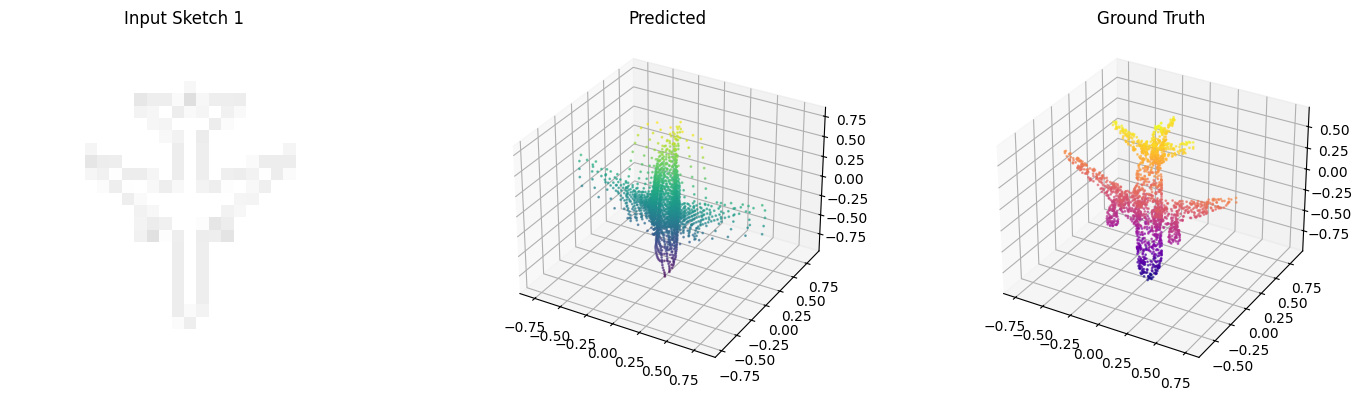

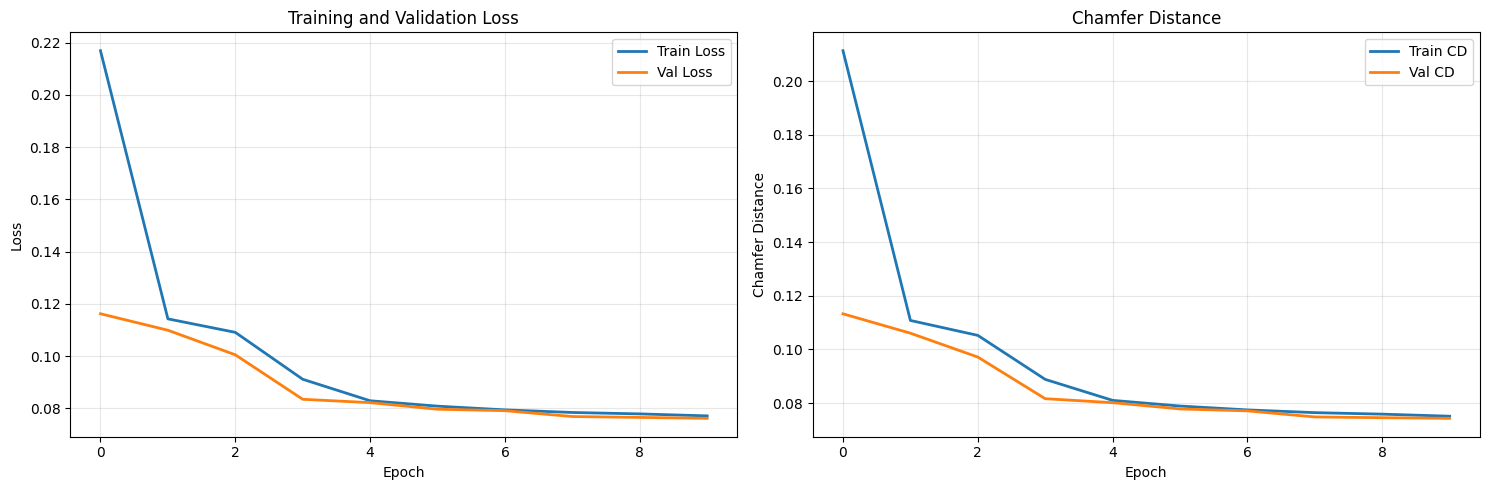


Epoch 11/150
----------------------------------------
Train Loss: 0.076628 | Val Loss: 0.076839
Train CD: 0.074533 | Val CD: 0.074630
LR: 0.000100

Epoch 12/150
----------------------------------------
Train Loss: 0.076291 | Val Loss: 0.077188
Train CD: 0.074187 | Val CD: 0.075120
LR: 0.000100

Epoch 13/150
----------------------------------------
Train Loss: 0.075966 | Val Loss: 0.076064
Train CD: 0.073861 | Val CD: 0.073830
LR: 0.000100
✓ Saved best model!

Epoch 14/150
----------------------------------------
Train Loss: 0.075745 | Val Loss: 0.076014
Train CD: 0.073640 | Val CD: 0.073806
LR: 0.000100
✓ Saved best model!

Epoch 15/150
----------------------------------------
Train Loss: 0.075439 | Val Loss: 0.074593
Train CD: 0.073333 | Val CD: 0.072390
LR: 0.000100
✓ Saved best model!
✓ Saved checkpoint at epoch 15

Epoch 16/150
----------------------------------------
Train Loss: 0.075353 | Val Loss: 0.075056
Train CD: 0.073258 | Val CD: 0.073023
LR: 0.000100

Epoch 17/150
-------

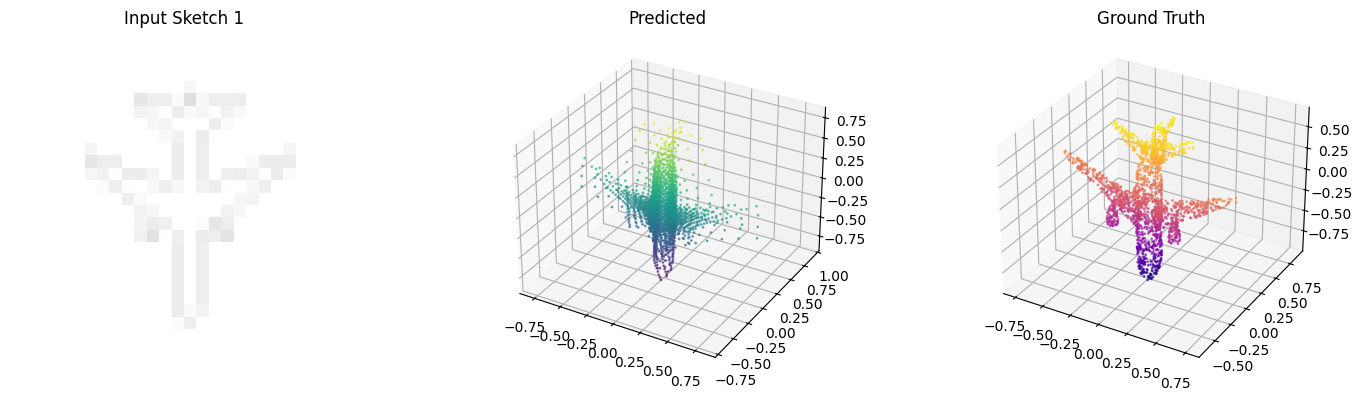

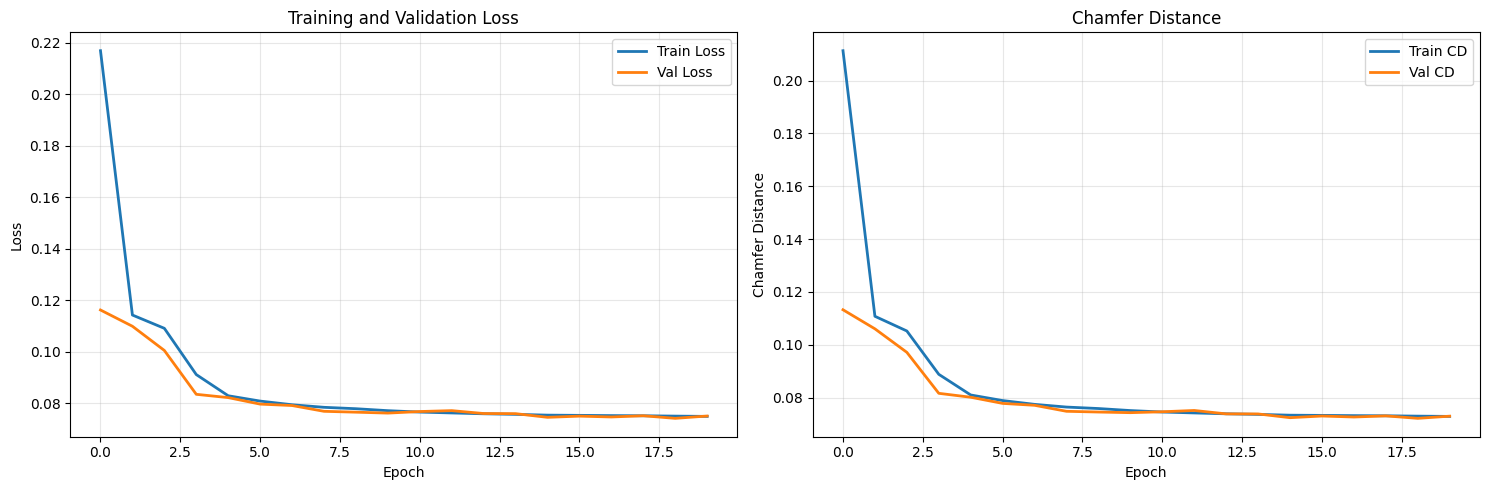


Epoch 21/150
----------------------------------------
Train Loss: 0.074834 | Val Loss: 0.074141
Train CD: 0.072763 | Val CD: 0.072036
LR: 0.000100
✓ Saved best model!

Epoch 22/150
----------------------------------------
Train Loss: 0.074739 | Val Loss: 0.073902
Train CD: 0.072669 | Val CD: 0.071822
LR: 0.000100
✓ Saved best model!

Epoch 23/150
----------------------------------------
Train Loss: 0.074787 | Val Loss: 0.074285
Train CD: 0.072724 | Val CD: 0.072332
LR: 0.000100

Epoch 24/150
----------------------------------------
Train Loss: 0.074502 | Val Loss: 0.074628
Train CD: 0.072435 | Val CD: 0.072748
LR: 0.000100

Epoch 25/150
----------------------------------------
Train Loss: 0.074588 | Val Loss: 0.074889
Train CD: 0.072525 | Val CD: 0.072916
LR: 0.000100
✓ Saved checkpoint at epoch 25

Epoch 26/150
----------------------------------------
Train Loss: 0.074452 | Val Loss: 0.073956
Train CD: 0.072386 | Val CD: 0.072003
LR: 0.000100

Epoch 27/150
---------------------------

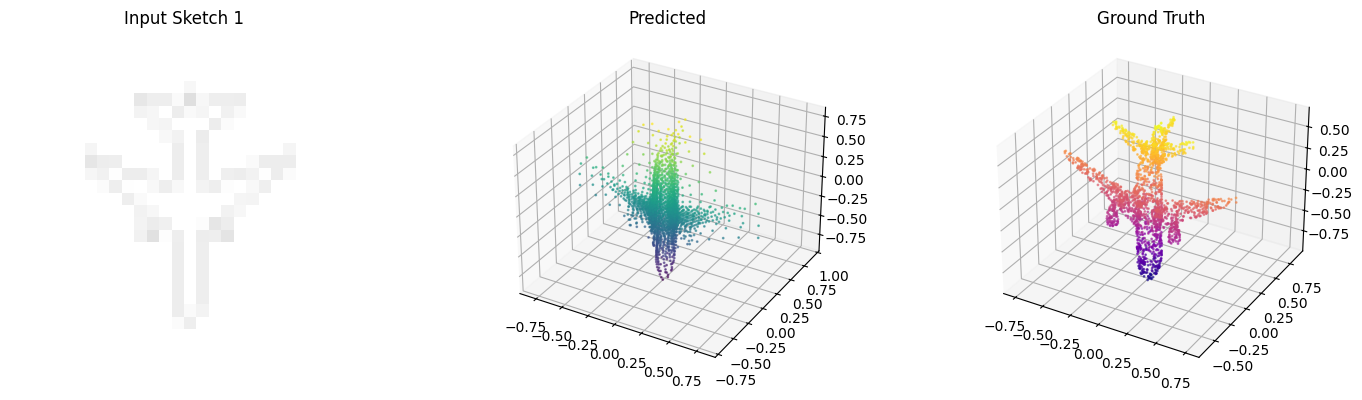

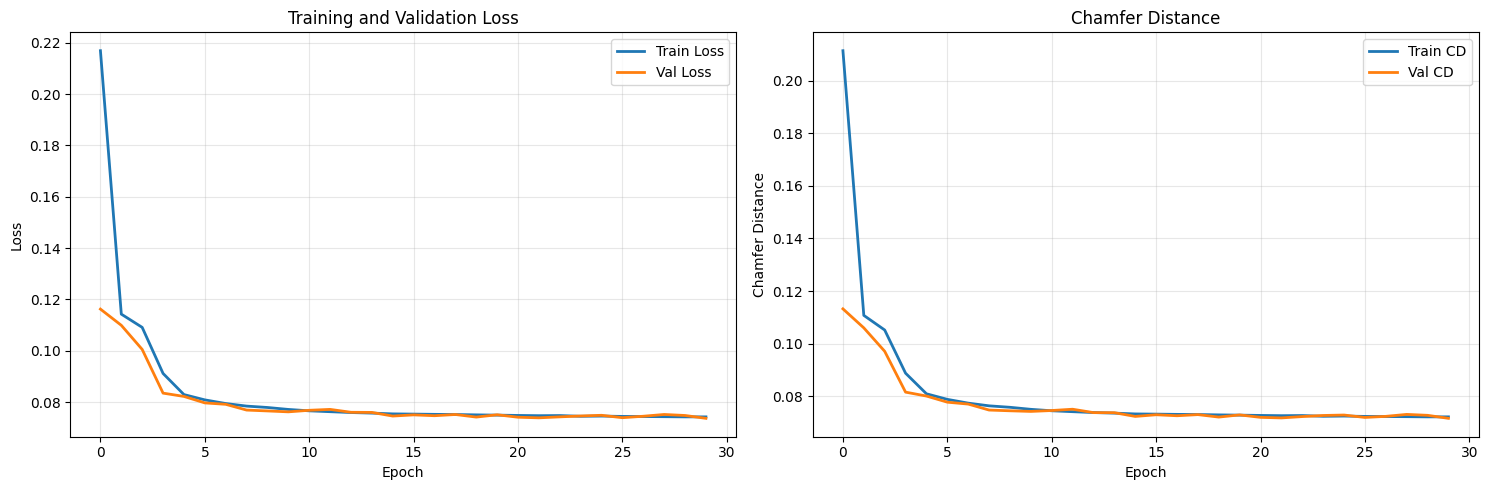


Epoch 31/150
----------------------------------------
Train Loss: 0.073740 | Val Loss: 0.073539
Train CD: 0.071690 | Val CD: 0.071607
LR: 0.000050
✓ Saved best model!

Epoch 32/150
----------------------------------------
Train Loss: 0.073738 | Val Loss: 0.073194
Train CD: 0.071696 | Val CD: 0.071143
LR: 0.000050
✓ Saved best model!

Epoch 33/150
----------------------------------------
Train Loss: 0.073763 | Val Loss: 0.073575
Train CD: 0.071725 | Val CD: 0.071567
LR: 0.000050

Epoch 34/150
----------------------------------------
Train Loss: 0.073718 | Val Loss: 0.073552
Train CD: 0.071682 | Val CD: 0.071488
LR: 0.000050

Epoch 35/150
----------------------------------------
Train Loss: 0.073703 | Val Loss: 0.073508
Train CD: 0.071666 | Val CD: 0.071446
LR: 0.000050
✓ Saved checkpoint at epoch 35

Epoch 36/150
----------------------------------------
Train Loss: 0.073670 | Val Loss: 0.073384
Train CD: 0.071635 | Val CD: 0.071221
LR: 0.000050

Epoch 37/150
---------------------------

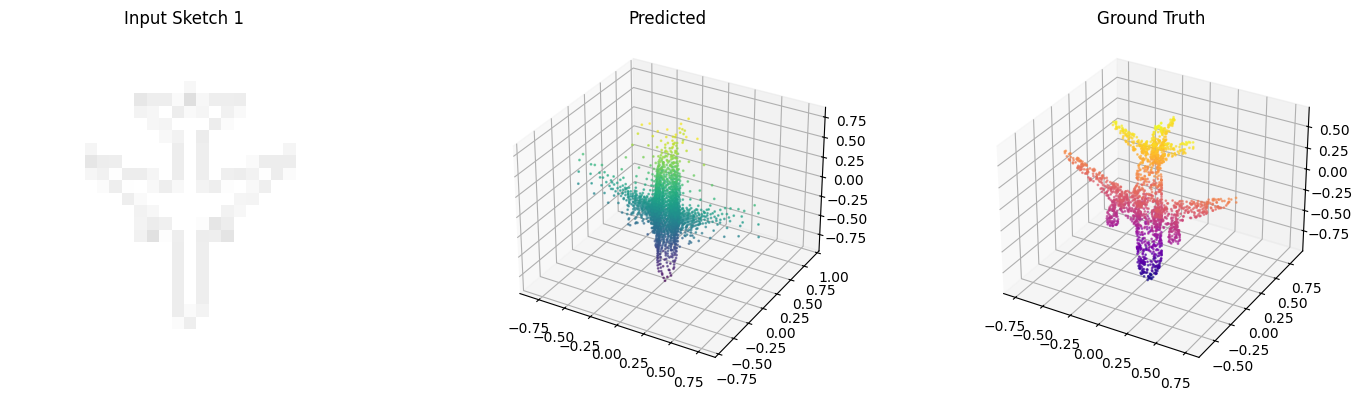

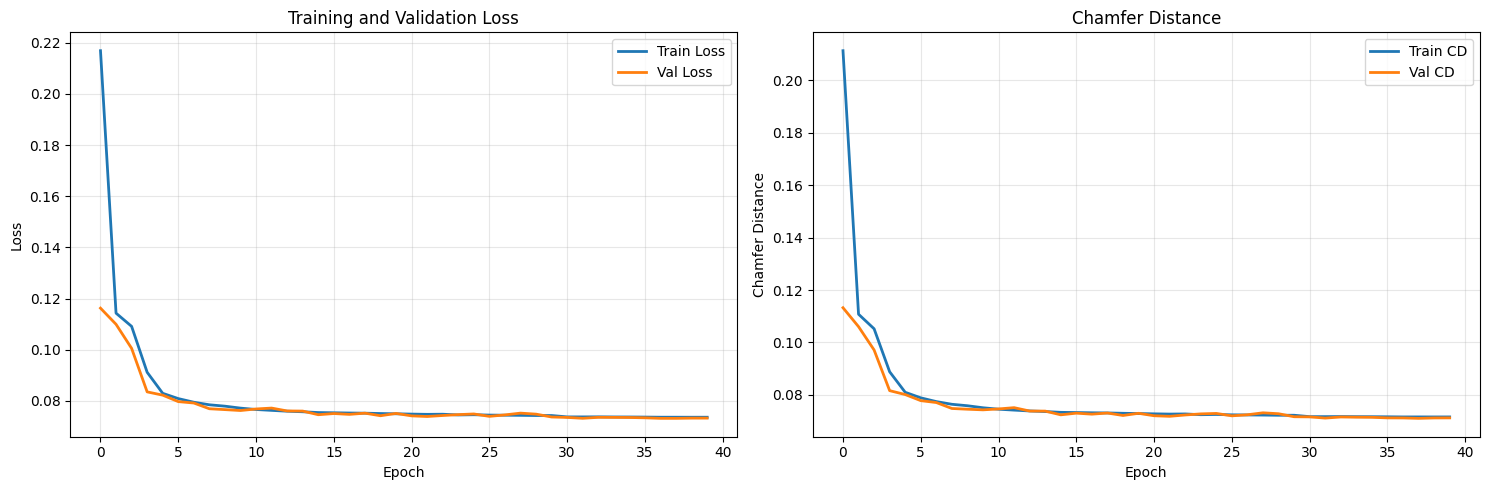


Epoch 41/150
----------------------------------------
Train Loss: 0.073561 | Val Loss: 0.073369
Train CD: 0.071535 | Val CD: 0.071340
LR: 0.000050

Epoch 42/150
----------------------------------------
Train Loss: 0.073562 | Val Loss: 0.073265
Train CD: 0.071531 | Val CD: 0.071307
LR: 0.000050

Epoch 43/150
----------------------------------------
Train Loss: 0.073519 | Val Loss: 0.073175
Train CD: 0.071494 | Val CD: 0.071117
LR: 0.000050
✓ Saved best model!

Epoch 44/150
----------------------------------------
Train Loss: 0.073526 | Val Loss: 0.073188
Train CD: 0.071503 | Val CD: 0.071177
LR: 0.000050

Epoch 45/150
----------------------------------------
Train Loss: 0.073533 | Val Loss: 0.073572
Train CD: 0.071509 | Val CD: 0.071588
LR: 0.000050
✓ Saved checkpoint at epoch 45

Epoch 46/150
----------------------------------------
Train Loss: 0.073510 | Val Loss: 0.073028
Train CD: 0.071487 | Val CD: 0.070988
LR: 0.000050
✓ Saved best model!

Epoch 47/150
---------------------------

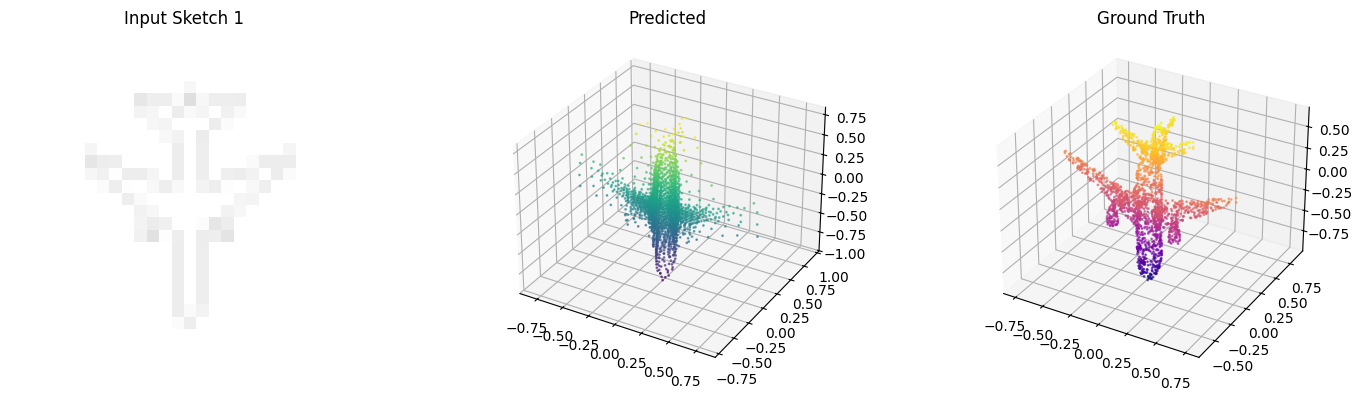

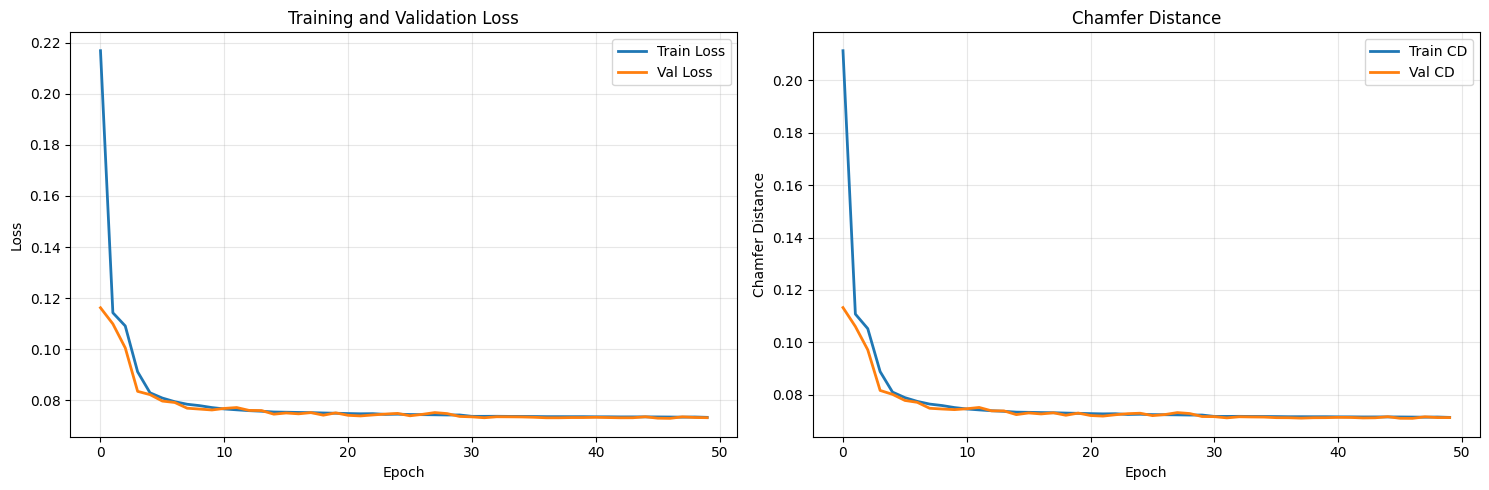


Epoch 51/150
----------------------------------------
Train Loss: 0.073393 | Val Loss: 0.073162
Train CD: 0.071373 | Val CD: 0.071105
LR: 0.000050

Epoch 52/150
----------------------------------------
Train Loss: 0.073411 | Val Loss: 0.072887
Train CD: 0.071397 | Val CD: 0.070872
LR: 0.000050
✓ Saved best model!

Epoch 53/150
----------------------------------------
Train Loss: 0.073308 | Val Loss: 0.073243
Train CD: 0.071295 | Val CD: 0.071214
LR: 0.000050

Epoch 54/150
----------------------------------------
Train Loss: 0.073319 | Val Loss: 0.072899
Train CD: 0.071303 | Val CD: 0.070848
LR: 0.000050

Epoch 55/150
----------------------------------------
Train Loss: 0.073378 | Val Loss: 0.072988
Train CD: 0.071368 | Val CD: 0.071075
LR: 0.000050
✓ Saved checkpoint at epoch 55

Epoch 56/150
----------------------------------------
Train Loss: 0.073293 | Val Loss: 0.072969
Train CD: 0.071284 | Val CD: 0.070950
LR: 0.000050

Epoch 57/150
----------------------------------------
Train 

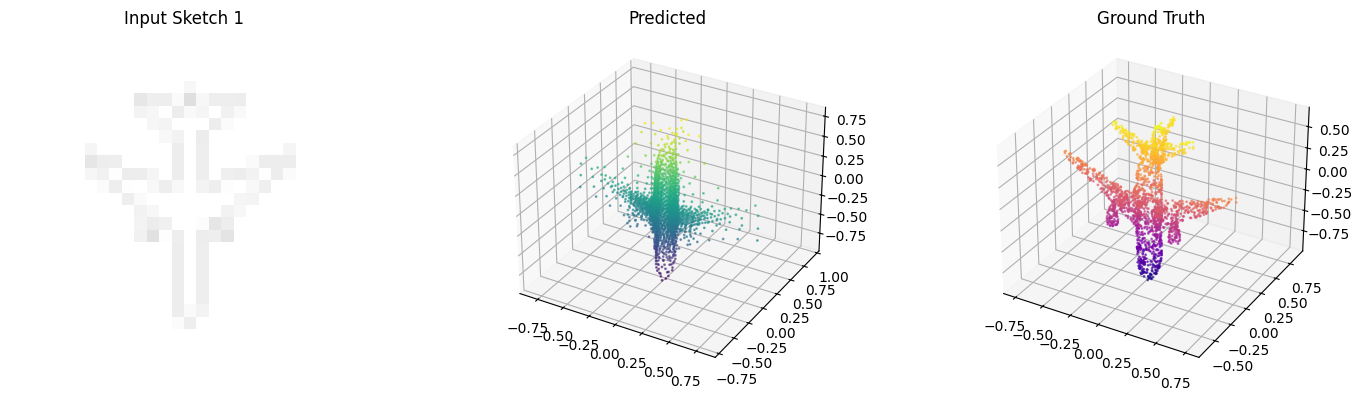

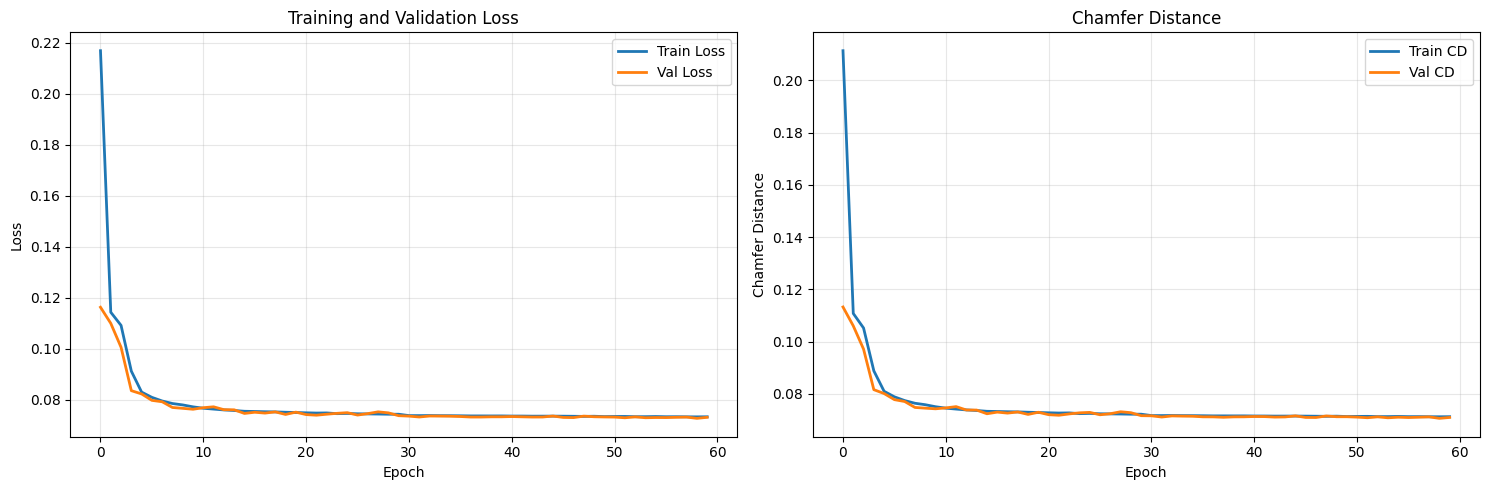


Epoch 61/150
----------------------------------------
Train Loss: 0.073049 | Val Loss: 0.072770
Train CD: 0.071043 | Val CD: 0.070763
LR: 0.000025

Epoch 62/150
----------------------------------------
Train Loss: 0.073035 | Val Loss: 0.072661
Train CD: 0.071027 | Val CD: 0.070703
LR: 0.000025
✓ Saved best model!

Epoch 63/150
----------------------------------------
Train Loss: 0.073011 | Val Loss: 0.072566
Train CD: 0.071005 | Val CD: 0.070563
LR: 0.000025
✓ Saved best model!

Epoch 64/150
----------------------------------------
Train Loss: 0.073007 | Val Loss: 0.072704
Train CD: 0.071005 | Val CD: 0.070618
LR: 0.000025

Epoch 65/150
----------------------------------------
Train Loss: 0.072972 | Val Loss: 0.072596
Train CD: 0.070967 | Val CD: 0.070570
LR: 0.000025
✓ Saved checkpoint at epoch 65

Epoch 66/150
----------------------------------------
Train Loss: 0.072995 | Val Loss: 0.072828
Train CD: 0.070992 | Val CD: 0.070793
LR: 0.000025

Epoch 67/150
---------------------------

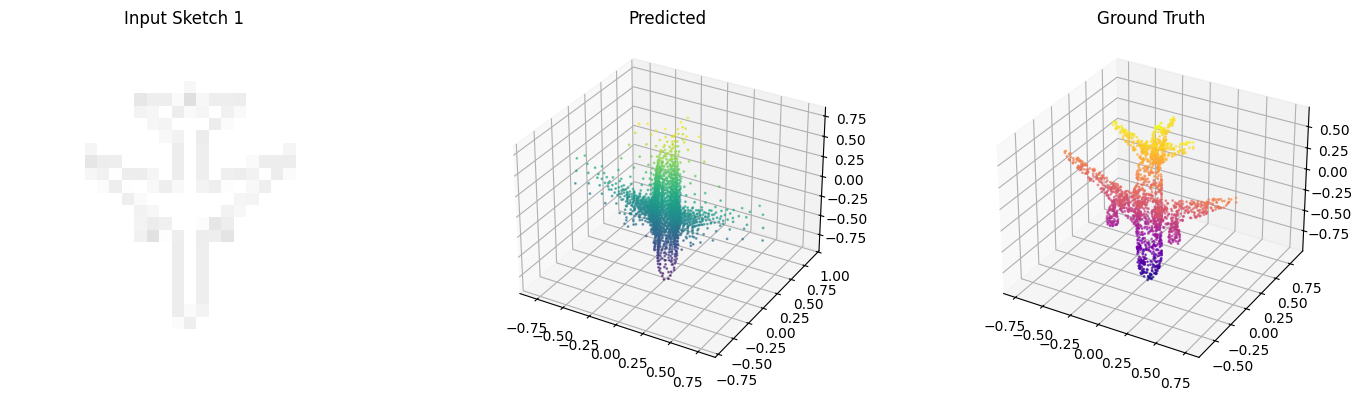

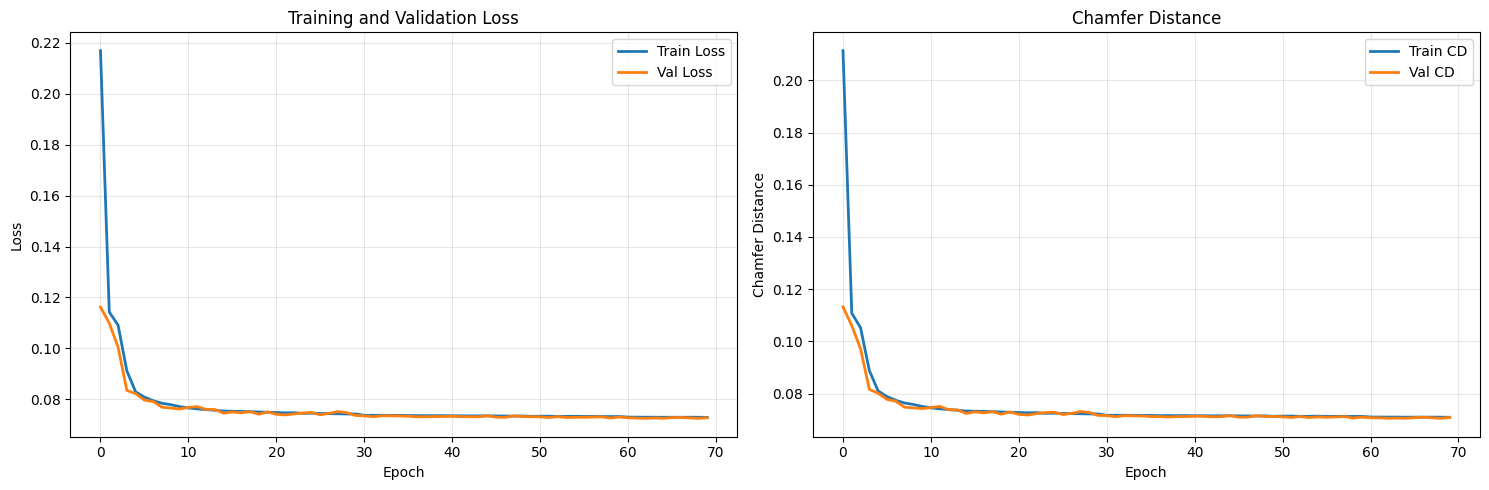


Epoch 71/150
----------------------------------------
Train Loss: 0.072968 | Val Loss: 0.072731
Train CD: 0.070967 | Val CD: 0.070761
LR: 0.000025

Epoch 72/150
----------------------------------------
Train Loss: 0.072944 | Val Loss: 0.072602
Train CD: 0.070942 | Val CD: 0.070577
LR: 0.000025

Epoch 73/150
----------------------------------------
Train Loss: 0.072940 | Val Loss: 0.072658
Train CD: 0.070937 | Val CD: 0.070598
LR: 0.000025

Epoch 74/150
----------------------------------------
Train Loss: 0.072950 | Val Loss: 0.072661
Train CD: 0.070945 | Val CD: 0.070690
LR: 0.000025

Epoch 75/150
----------------------------------------
Train Loss: 0.072942 | Val Loss: 0.072511
Train CD: 0.070943 | Val CD: 0.070521
LR: 0.000025
✓ Saved best model!
✓ Saved checkpoint at epoch 75

Epoch 76/150
----------------------------------------
Train Loss: 0.072891 | Val Loss: 0.072626
Train CD: 0.070895 | Val CD: 0.070595
LR: 0.000025

Epoch 77/150
----------------------------------------
Train 

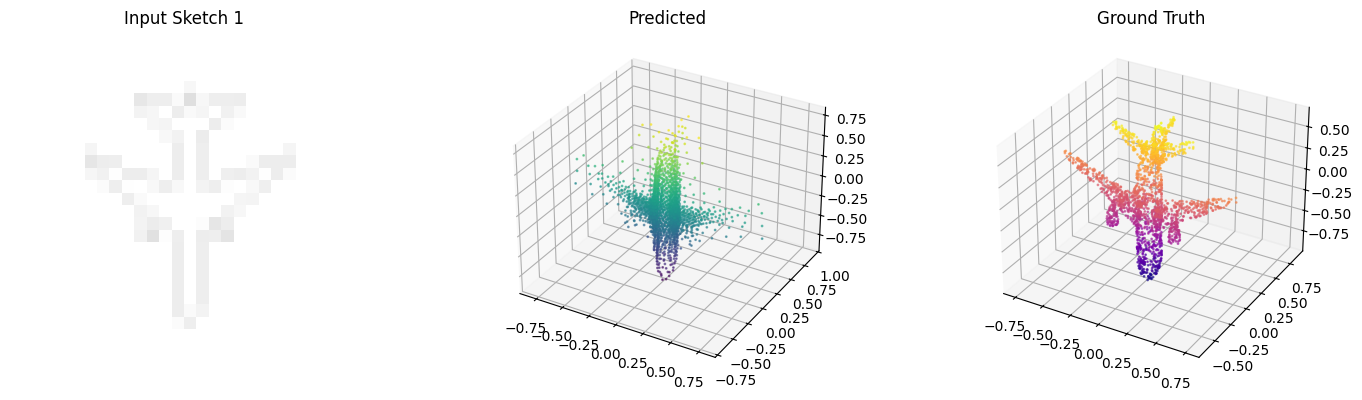

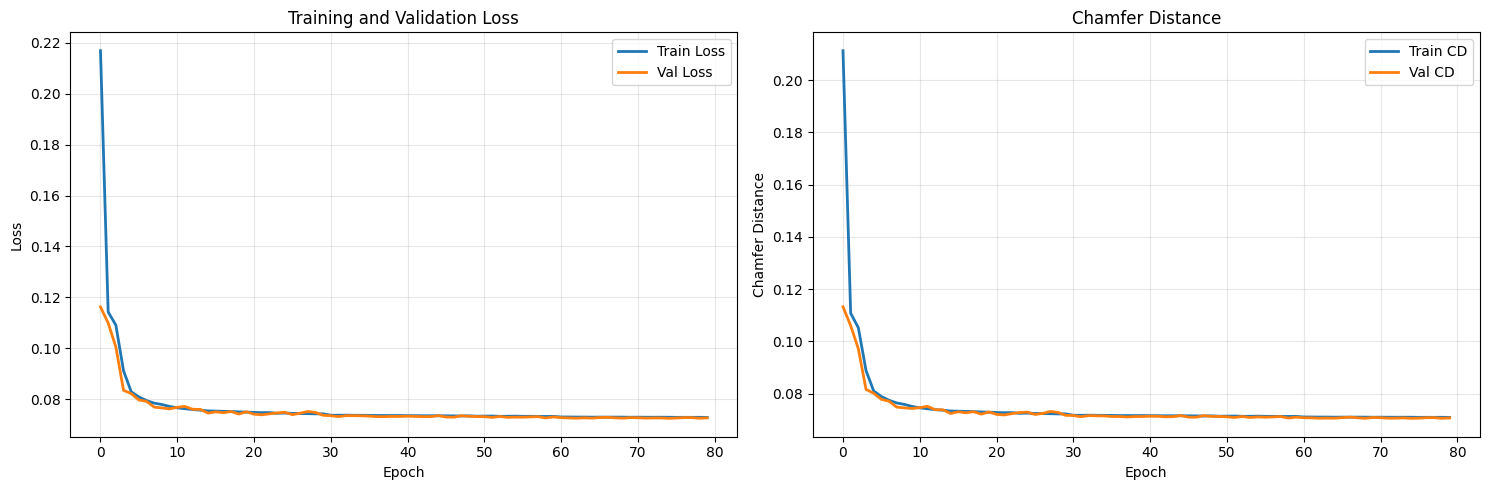


Epoch 81/150
----------------------------------------
Train Loss: 0.072866 | Val Loss: 0.072503
Train CD: 0.070868 | Val CD: 0.070456
LR: 0.000025
✓ Saved best model!

Epoch 82/150
----------------------------------------
Train Loss: 0.072887 | Val Loss: 0.072629
Train CD: 0.070891 | Val CD: 0.070644
LR: 0.000025

Epoch 83/150
----------------------------------------
Train Loss: 0.072887 | Val Loss: 0.072534
Train CD: 0.070890 | Val CD: 0.070573
LR: 0.000025

Epoch 84/150
----------------------------------------
Train Loss: 0.072889 | Val Loss: 0.072461
Train CD: 0.070896 | Val CD: 0.070476
LR: 0.000025
✓ Saved best model!

Epoch 85/150
----------------------------------------
Train Loss: 0.072893 | Val Loss: 0.072605
Train CD: 0.070899 | Val CD: 0.070569
LR: 0.000025
✓ Saved checkpoint at epoch 85

Epoch 86/150
----------------------------------------
Train Loss: 0.072854 | Val Loss: 0.072510
Train CD: 0.070860 | Val CD: 0.070457
LR: 0.000025

Epoch 87/150
---------------------------

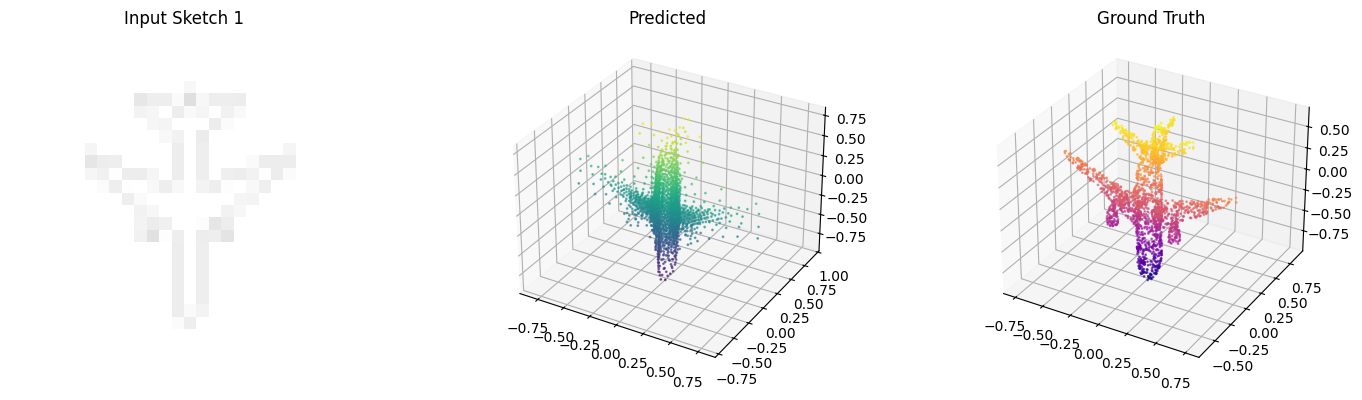

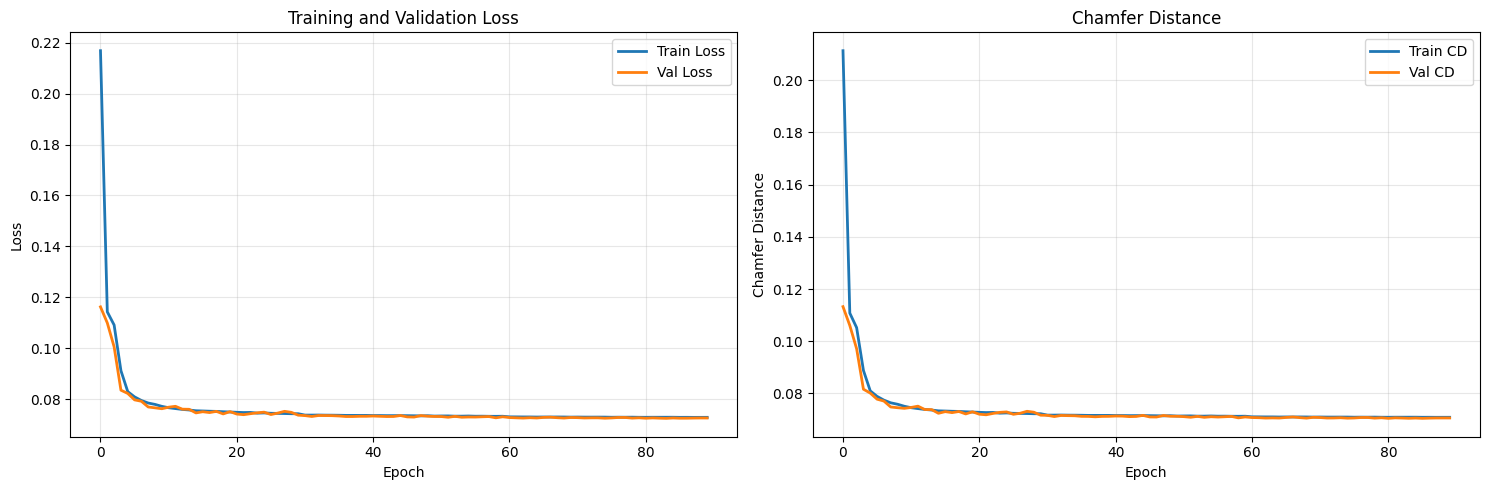


Epoch 91/150
----------------------------------------
Train Loss: 0.072715 | Val Loss: 0.072458
Train CD: 0.070723 | Val CD: 0.070434
LR: 0.000013
✓ Saved best model!

Epoch 92/150
----------------------------------------
Train Loss: 0.072700 | Val Loss: 0.072476
Train CD: 0.070703 | Val CD: 0.070486
LR: 0.000013

Epoch 93/150
----------------------------------------
Train Loss: 0.072710 | Val Loss: 0.072477
Train CD: 0.070717 | Val CD: 0.070416
LR: 0.000013

Epoch 94/150
----------------------------------------
Train Loss: 0.072691 | Val Loss: 0.072441
Train CD: 0.070697 | Val CD: 0.070472
LR: 0.000013
✓ Saved best model!

Epoch 95/150
----------------------------------------
Train Loss: 0.072704 | Val Loss: 0.072368
Train CD: 0.070714 | Val CD: 0.070356
LR: 0.000013
✓ Saved best model!
✓ Saved checkpoint at epoch 95

Epoch 96/150
----------------------------------------
Train Loss: 0.072692 | Val Loss: 0.072534
Train CD: 0.070699 | Val CD: 0.070557
LR: 0.000013

Epoch 97/150
-------

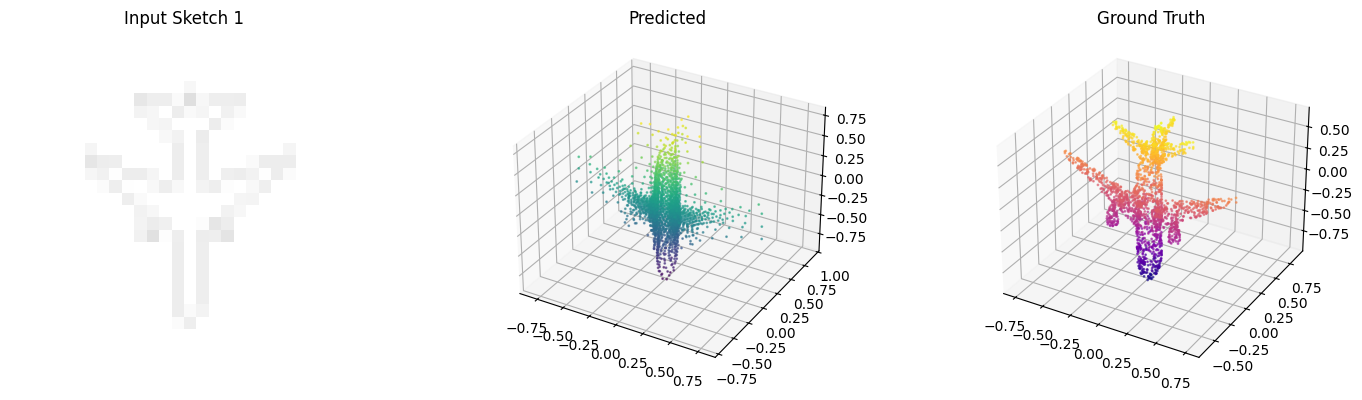

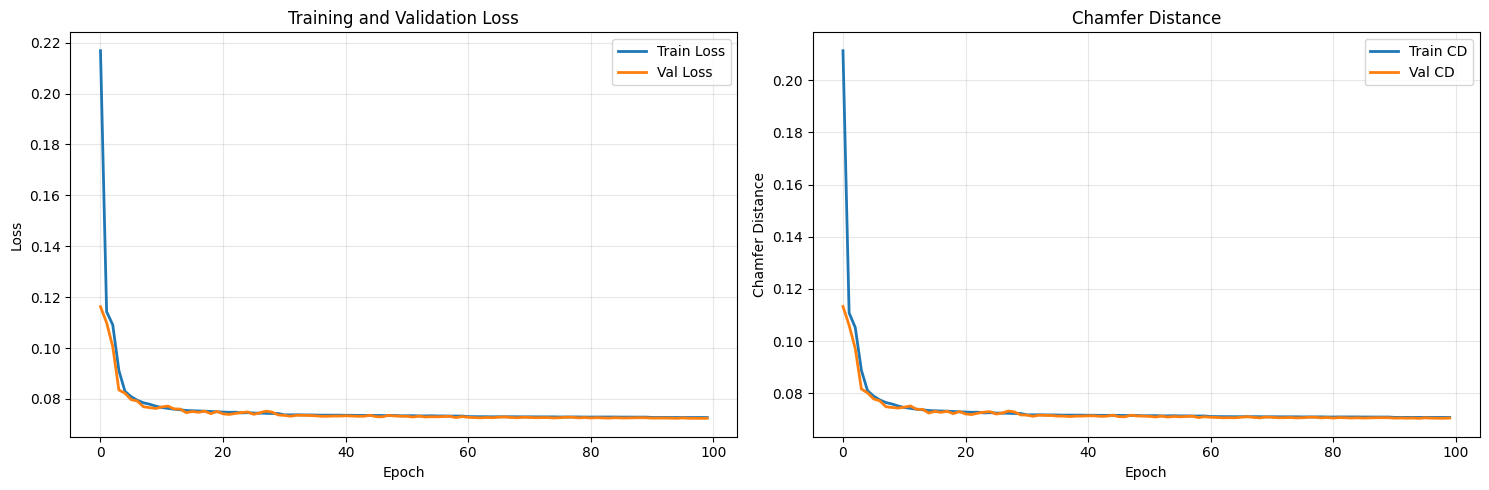


Epoch 101/150
----------------------------------------
Train Loss: 0.072673 | Val Loss: 0.072350
Train CD: 0.070684 | Val CD: 0.070339
LR: 0.000013
✓ Saved best model!

Epoch 102/150
----------------------------------------
Train Loss: 0.072672 | Val Loss: 0.072368
Train CD: 0.070682 | Val CD: 0.070408
LR: 0.000013

Epoch 103/150
----------------------------------------
Train Loss: 0.072689 | Val Loss: 0.072374
Train CD: 0.070700 | Val CD: 0.070335
LR: 0.000013

Epoch 104/150
----------------------------------------
Train Loss: 0.072694 | Val Loss: 0.072317
Train CD: 0.070705 | Val CD: 0.070336
LR: 0.000013
✓ Saved best model!

Epoch 105/150
----------------------------------------
Train Loss: 0.072662 | Val Loss: 0.072419
Train CD: 0.070673 | Val CD: 0.070384
LR: 0.000013
✓ Saved checkpoint at epoch 105

Epoch 106/150
----------------------------------------
Train Loss: 0.072665 | Val Loss: 0.072322
Train CD: 0.070677 | Val CD: 0.070326
LR: 0.000013

Epoch 107/150
-------------------

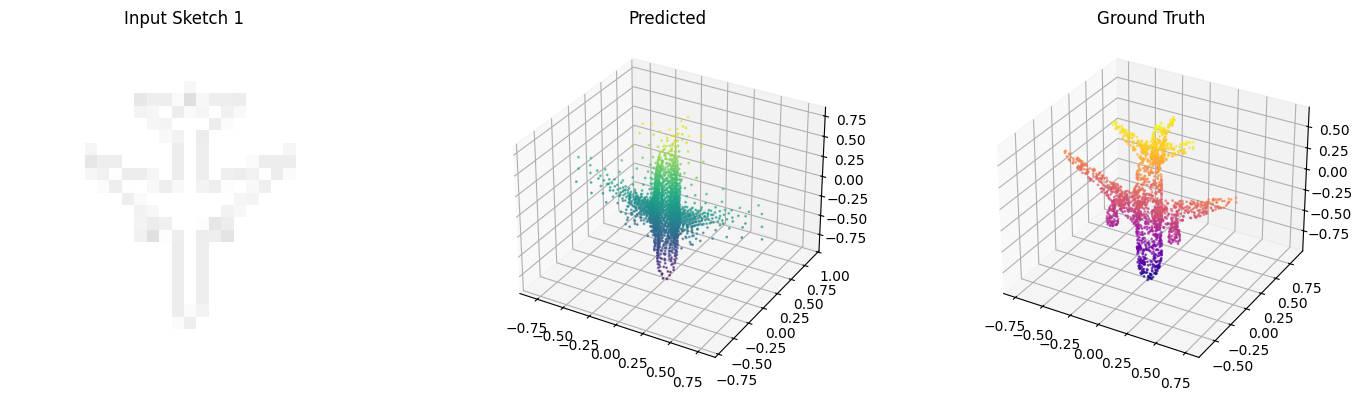

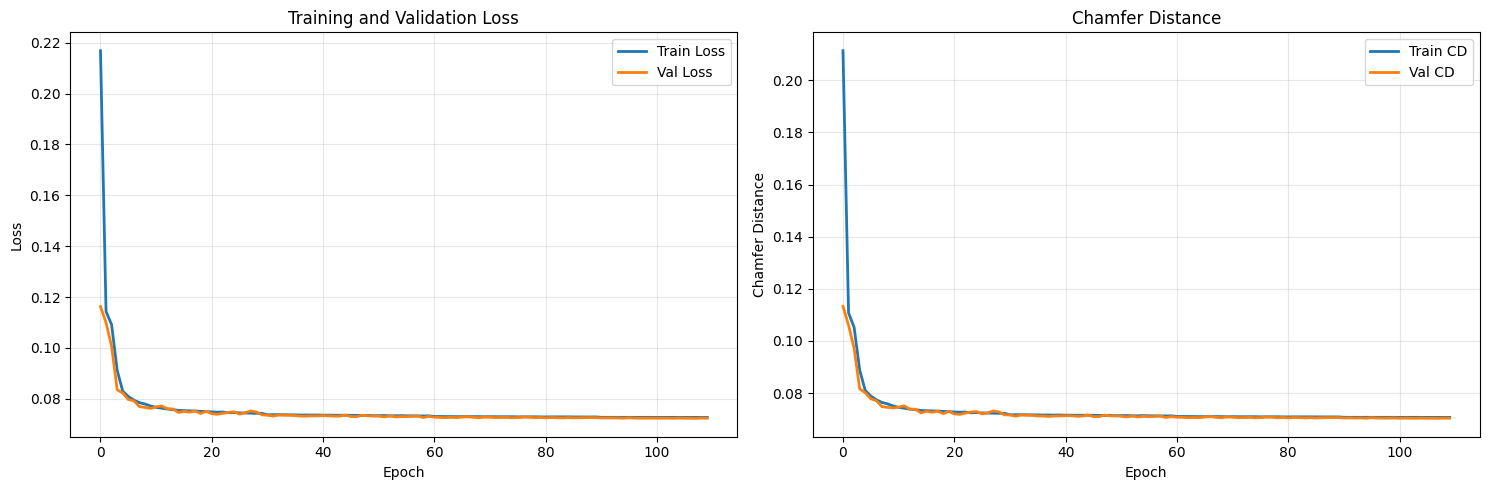


Epoch 111/150
----------------------------------------
Train Loss: 0.072653 | Val Loss: 0.072321
Train CD: 0.070664 | Val CD: 0.070339
LR: 0.000013

Epoch 112/150
----------------------------------------
Train Loss: 0.072667 | Val Loss: 0.072316
Train CD: 0.070680 | Val CD: 0.070320
LR: 0.000013

Epoch 113/150
----------------------------------------
Train Loss: 0.072650 | Val Loss: 0.072292
Train CD: 0.070662 | Val CD: 0.070277
LR: 0.000013
✓ Saved best model!

Epoch 114/150
----------------------------------------
Train Loss: 0.072660 | Val Loss: 0.072392
Train CD: 0.070673 | Val CD: 0.070419
LR: 0.000013

Epoch 115/150
----------------------------------------
Train Loss: 0.072651 | Val Loss: 0.072319
Train CD: 0.070666 | Val CD: 0.070299
LR: 0.000013
✓ Saved checkpoint at epoch 115

Epoch 116/150
----------------------------------------
Train Loss: 0.072642 | Val Loss: 0.072331
Train CD: 0.070653 | Val CD: 0.070376
LR: 0.000013

Epoch 117/150
---------------------------------------

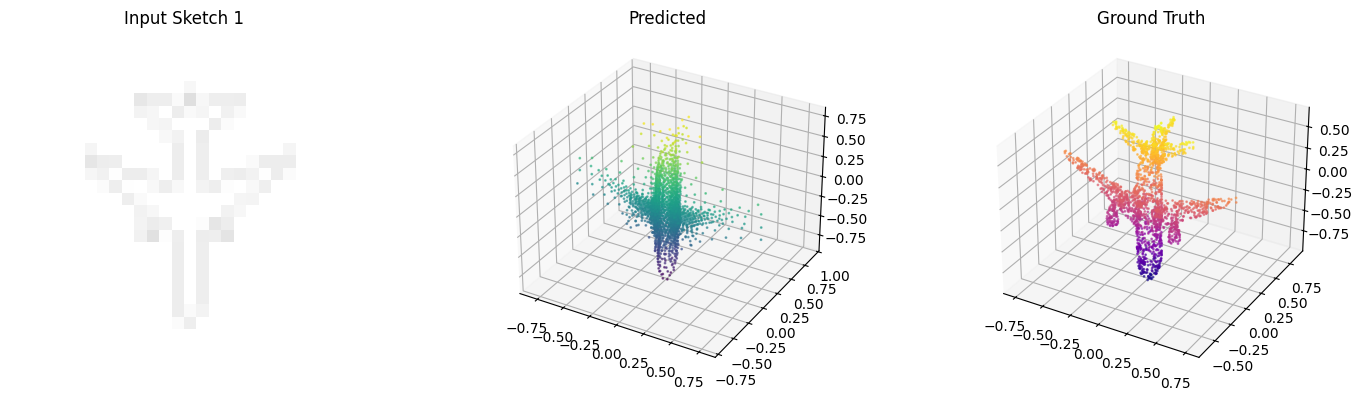

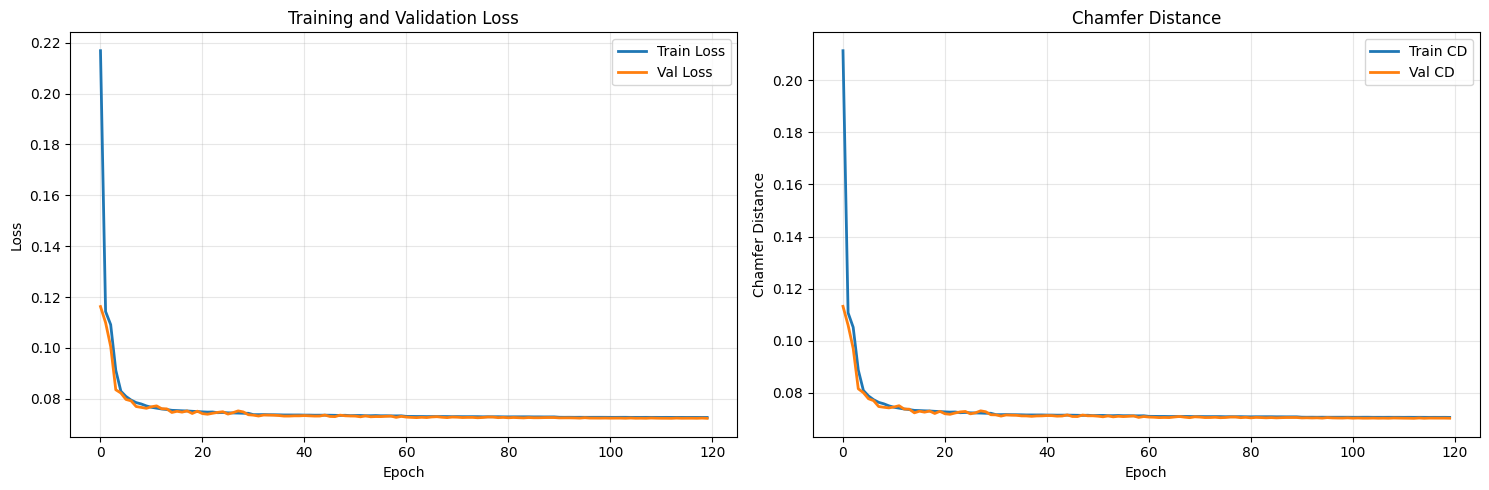


Epoch 121/150
----------------------------------------
Train Loss: 0.072557 | Val Loss: 0.072230
Train CD: 0.070573 | Val CD: 0.070271
LR: 0.000006
✓ Saved best model!

Epoch 122/150
----------------------------------------
Train Loss: 0.072567 | Val Loss: 0.072272
Train CD: 0.070583 | Val CD: 0.070318
LR: 0.000006

Epoch 123/150
----------------------------------------
Train Loss: 0.072571 | Val Loss: 0.072241
Train CD: 0.070589 | Val CD: 0.070257
LR: 0.000006

Epoch 124/150
----------------------------------------
Train Loss: 0.072569 | Val Loss: 0.072224
Train CD: 0.070588 | Val CD: 0.070239
LR: 0.000006
✓ Saved best model!

Epoch 125/150
----------------------------------------
Train Loss: 0.072569 | Val Loss: 0.072286
Train CD: 0.070584 | Val CD: 0.070286
LR: 0.000006
✓ Saved checkpoint at epoch 125

Epoch 126/150
----------------------------------------
Train Loss: 0.072564 | Val Loss: 0.072255
Train CD: 0.070582 | Val CD: 0.070235
LR: 0.000006

Epoch 127/150
-------------------

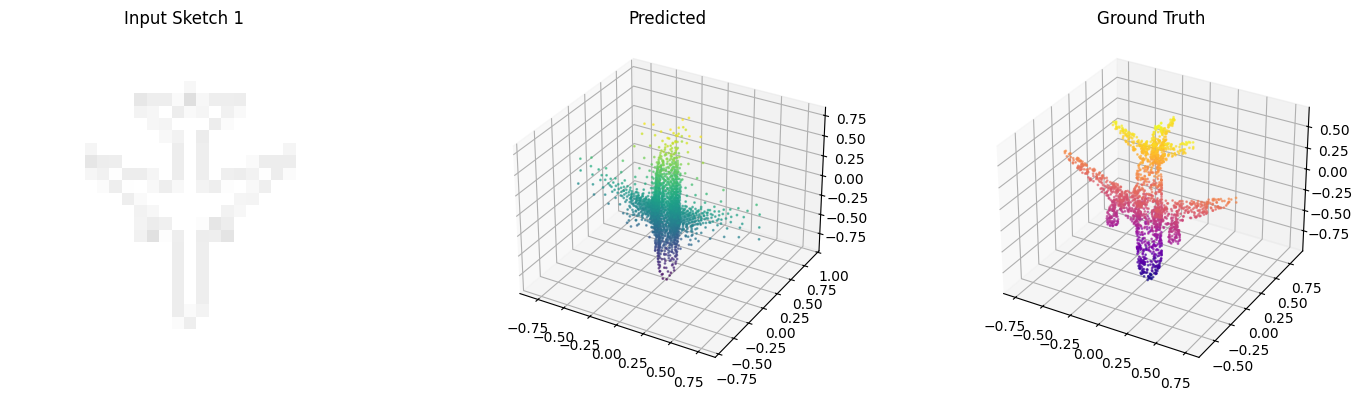

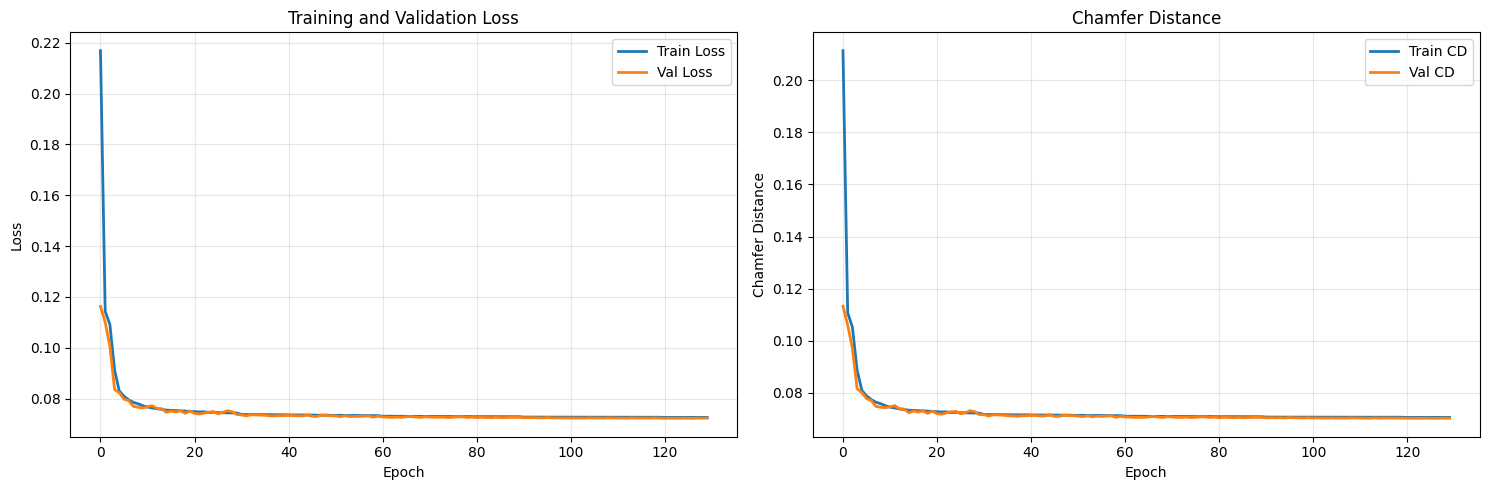


Epoch 131/150
----------------------------------------
Train Loss: 0.072554 | Val Loss: 0.072227
Train CD: 0.070572 | Val CD: 0.070228
LR: 0.000006

Epoch 132/150
----------------------------------------
Train Loss: 0.072549 | Val Loss: 0.072350
Train CD: 0.070569 | Val CD: 0.070371
LR: 0.000006

Epoch 133/150
----------------------------------------
Train Loss: 0.072564 | Val Loss: 0.072237
Train CD: 0.070583 | Val CD: 0.070249
LR: 0.000006

Epoch 134/150
----------------------------------------
Train Loss: 0.072553 | Val Loss: 0.072336
Train CD: 0.070570 | Val CD: 0.070409
LR: 0.000006

Epoch 135/150
----------------------------------------
Train Loss: 0.072548 | Val Loss: 0.072206
Train CD: 0.070568 | Val CD: 0.070245
LR: 0.000006
✓ Saved checkpoint at epoch 135

Epoch 136/150
----------------------------------------
Train Loss: 0.072557 | Val Loss: 0.072252
Train CD: 0.070577 | Val CD: 0.070273
LR: 0.000006

Epoch 137/150
----------------------------------------
Train Loss: 0.0725

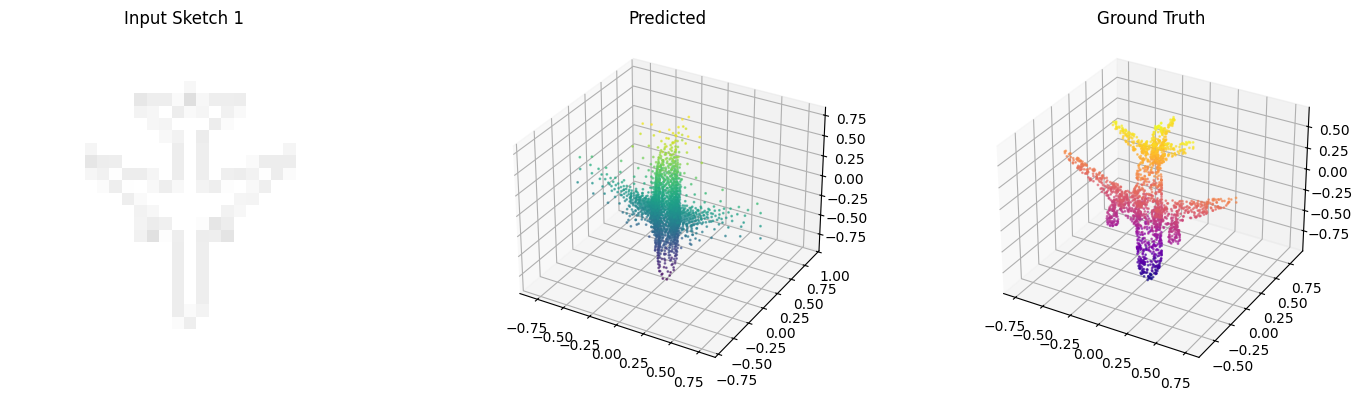

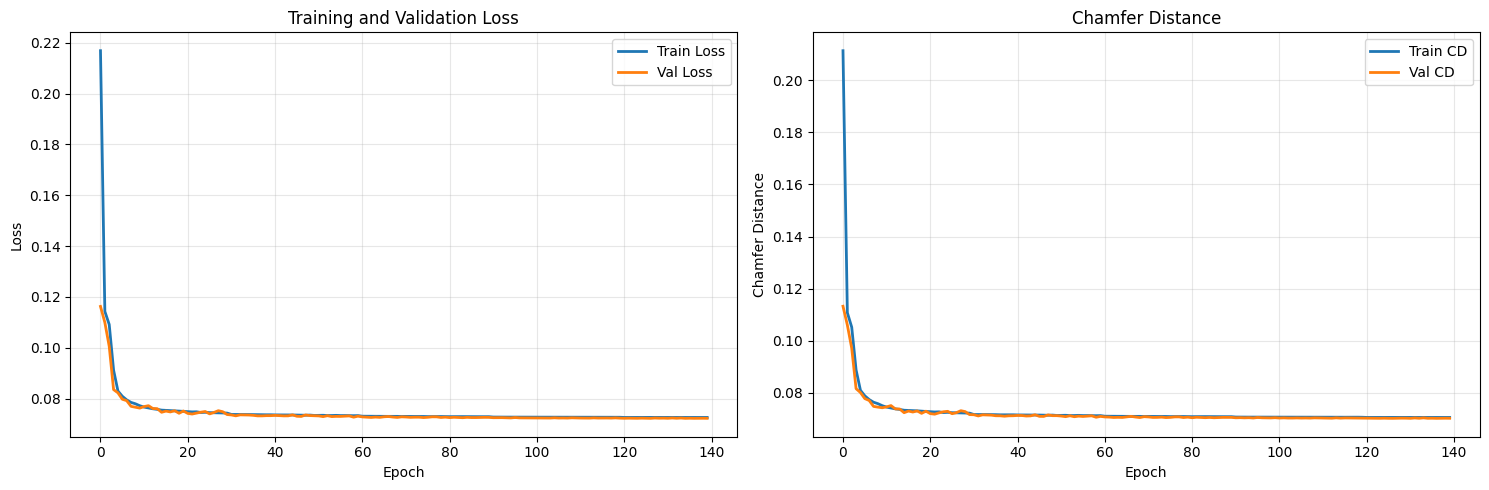


Epoch 141/150
----------------------------------------
Train Loss: 0.072548 | Val Loss: 0.072234
Train CD: 0.070565 | Val CD: 0.070278
LR: 0.000006

Epoch 142/150
----------------------------------------
Train Loss: 0.072557 | Val Loss: 0.072223
Train CD: 0.070578 | Val CD: 0.070239
LR: 0.000006

Epoch 143/150
----------------------------------------
Train Loss: 0.072539 | Val Loss: 0.072229
Train CD: 0.070564 | Val CD: 0.070240
LR: 0.000006

Epoch 144/150
----------------------------------------
Train Loss: 0.072545 | Val Loss: 0.072210
Train CD: 0.070561 | Val CD: 0.070248
LR: 0.000006

Epoch 145/150
----------------------------------------
Train Loss: 0.072549 | Val Loss: 0.072233
Train CD: 0.070572 | Val CD: 0.070258
LR: 0.000006
✓ Saved checkpoint at epoch 145

Epoch 146/150
----------------------------------------
Train Loss: 0.072544 | Val Loss: 0.072222
Train CD: 0.070564 | Val CD: 0.070232
LR: 0.000006

Epoch 147/150
----------------------------------------
Train Loss: 0.0725

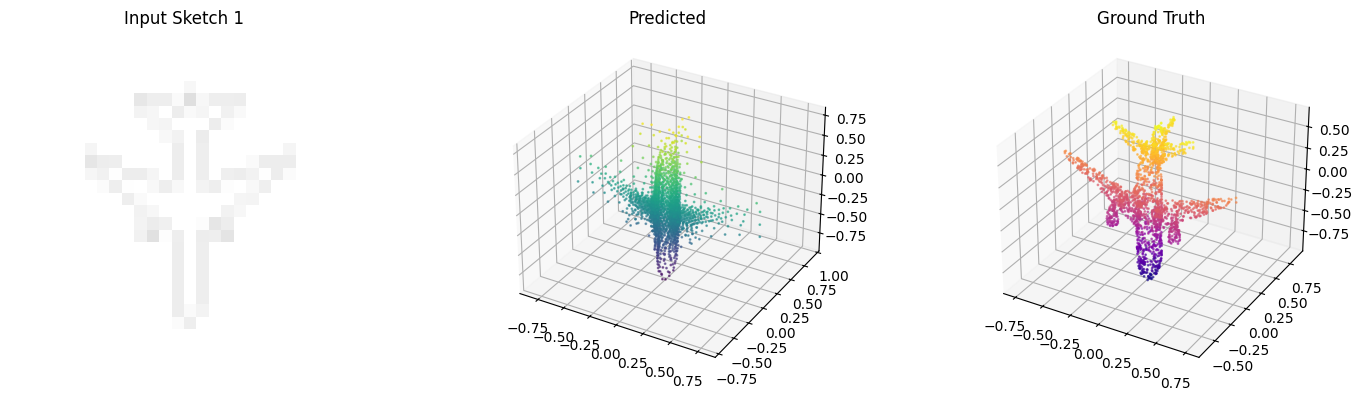

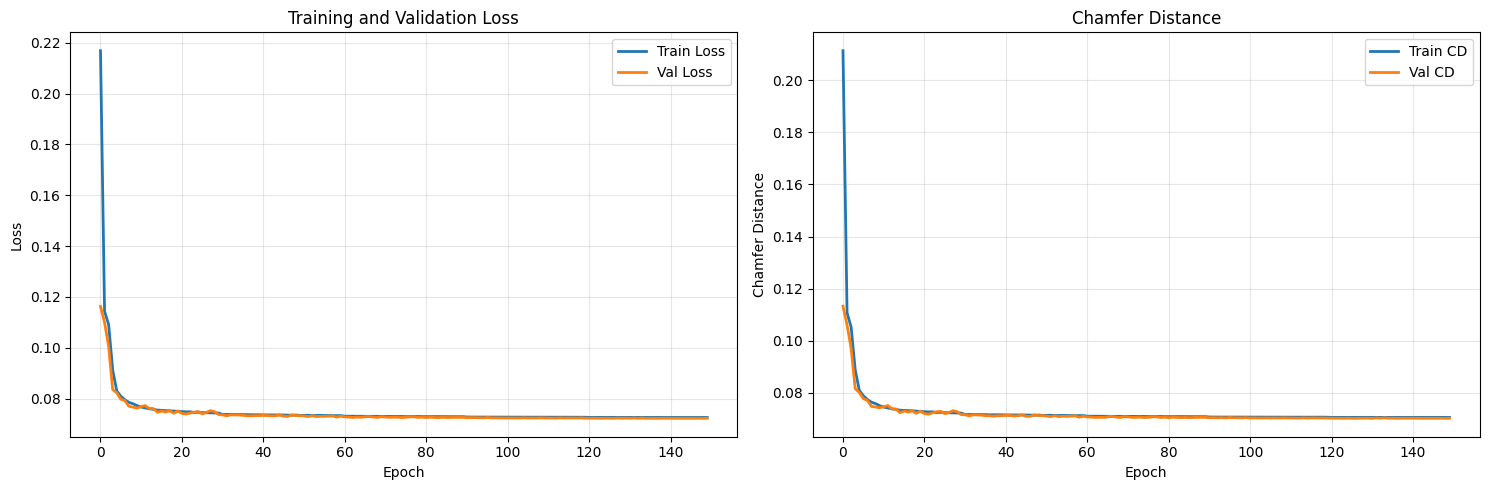


Training Complete!
Best validation loss: 0.072195


In [ ]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_cd': [],
    'val_cd': [],
    'lr': []
}

best_val_loss = float('inf')

print("="*60)
print("Starting Training!")
print("="*60)

for epoch in range(config.num_epochs):
    print(f"\nEpoch {epoch+1}/{config.num_epochs}")
    print("-" * 40)
    
    # Train
    train_loss, train_metrics = train_epoch(
        model, train_loader, optimizer, config, device
    )
    
    # Validate
    val_loss, val_cd = eval_epoch(model, val_loader, config, device)
    
    # Step scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_cd'].append(train_metrics['chamfer'])
    history['val_cd'].append(val_cd)
    history['lr'].append(current_lr)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    print(f"Train CD: {train_metrics['chamfer']:.6f} | Val CD: {val_cd:.6f}")
    print(f"LR: {current_lr:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss,
            'config': config
        }, os.path.join(config.save_dir, 'best_model.pt'))
        print("✓ Saved best model!")
    
    # Save checkpoint
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, os.path.join(config.save_dir, f'checkpoint_epoch_{epoch+1}.pt'))
        print(f"✓ Saved checkpoint at epoch {epoch+1}")
    
    # Visualize
    if (epoch + 1) % 10 == 0:
        fig = visualize_batch(model, val_loader, device, num_samples=1)
        plt.savefig(os.path.join(config.save_dir, f'viz_epoch_{epoch+1}.png'), 
                   dpi=150, bbox_inches='tight')
        plt.show()
        
        # Plot curves
        fig = plot_training_curves(history)
        plt.savefig(os.path.join(config.save_dir, 'training_curves.png'),
                   dpi=150, bbox_inches='tight')
        plt.show()

print("\n" + "="*60)
print("Training Complete!")
print(f"Best validation loss: {best_val_loss:.6f}")
print("="*60)

## 13. Final Evaluation and Visualization

Loaded best model from epoch 149
Best validation loss: 0.072195


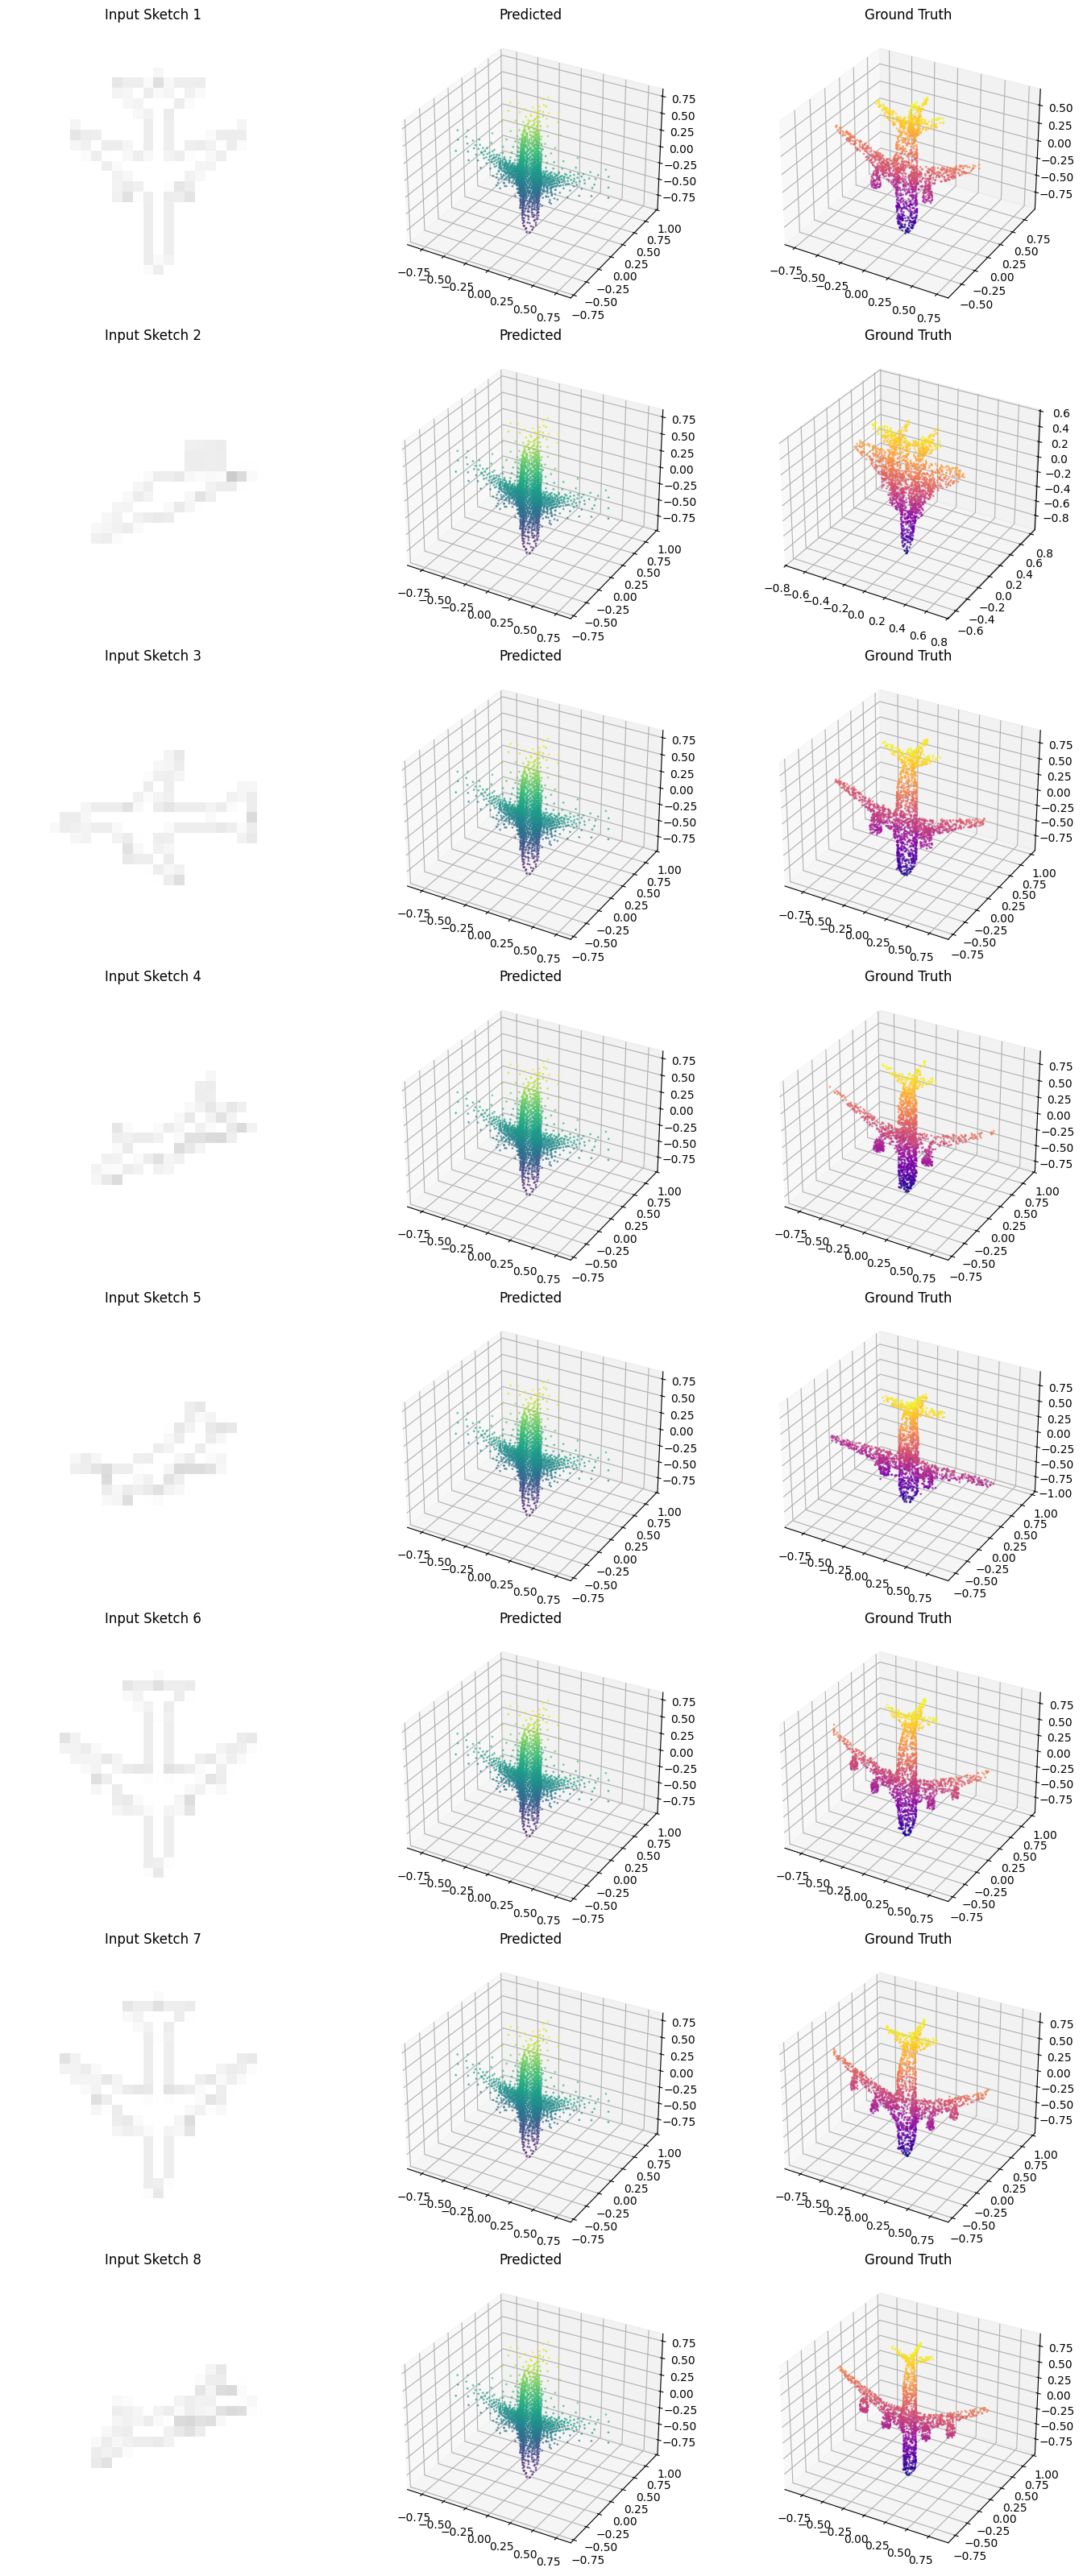

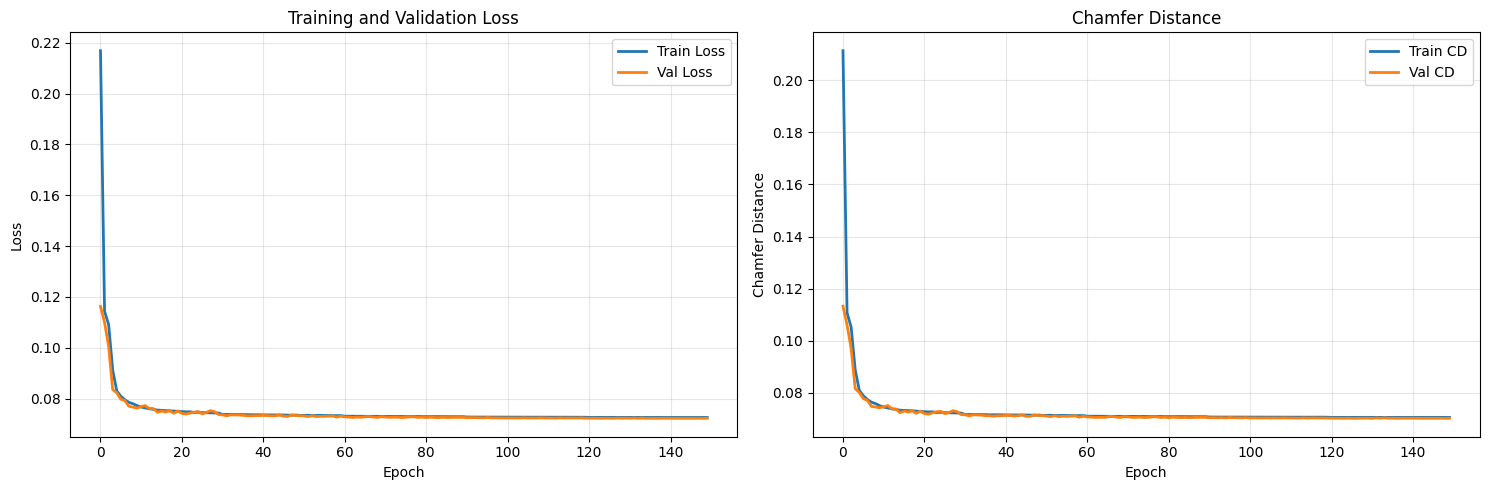

In [14]:
# Load best model
checkpoint = torch.load(
    os.path.join(config.save_dir, 'best_model.pt'),
    map_location=device,
    weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation loss: {checkpoint['val_loss']:.6f}")

# Final visualization
fig = visualize_batch(model, val_loader, device, num_samples=8)
plt.savefig(os.path.join(config.save_dir, 'final_results.png'),
           dpi=150, bbox_inches='tight')
plt.show()

# Plot final training curves
fig = plot_training_curves(history)
plt.savefig(os.path.join(config.save_dir, 'final_training_curves.png'),
           dpi=150, bbox_inches='tight')
plt.show()

## 14. Export Model for Inference

In [ ]:
torch.save(model.state_dict(), 'best_model_weights.pt')
print("✓ Model weights saved to 'best_model_weights.pt'")

torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'history': history,
    'best_val_loss': best_val_loss
}, 'complete_model.pt')
print("✓ Complete model saved to 'complete_model.pt'")

✓ Model weights saved to 'best_model_weights.pt'
✓ Complete model saved to 'complete_model.pt'


## 15. Test Inference on Sample

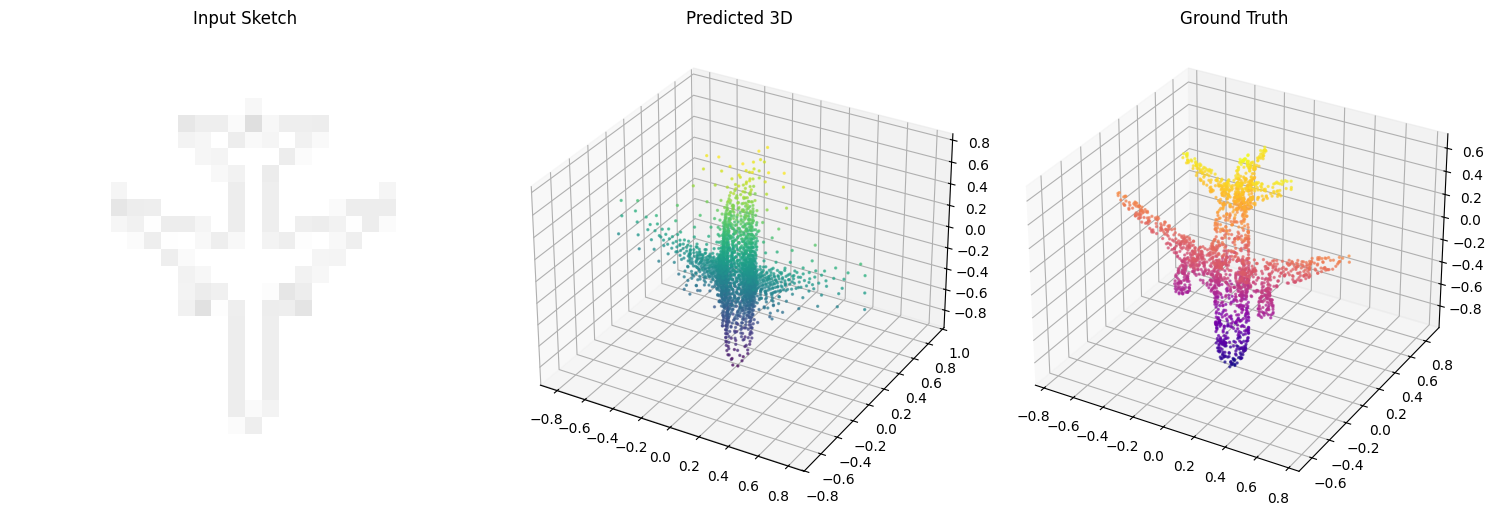

✓ Test prediction saved to 'test_prediction.npy'


In [16]:
# Get a test sample
test_img, test_gt = next(iter(val_loader))
test_img = test_img[0:1].to(device)
test_gt = test_gt[0:1]

# Predict
model.eval()
with torch.no_grad():
    pred_pc = model(test_img)

# Visualize
fig = plt.figure(figsize=(15, 5))

# Input
ax1 = fig.add_subplot(131)
img = test_img[0].cpu().numpy().transpose(1, 2, 0)
ax1.imshow(img)
ax1.set_title('Input Sketch')
ax1.axis('off')

# Prediction
ax2 = fig.add_subplot(132, projection='3d')
pred = pred_pc[0].cpu().numpy()
ax2.scatter(pred[:, 0], pred[:, 1], pred[:, 2],
           c=pred[:, 2], cmap='viridis', s=2, alpha=0.6)
ax2.set_title('Predicted 3D')
set_3d_axes_equal(ax2, pred)

# Ground truth
ax3 = fig.add_subplot(133, projection='3d')
gt = test_gt[0].numpy()
ax3.scatter(gt[:, 0], gt[:, 1], gt[:, 2],
           c=gt[:, 2], cmap='plasma', s=2, alpha=0.6)
ax3.set_title('Ground Truth')
set_3d_axes_equal(ax3, gt)

plt.tight_layout()
plt.show()

# Save prediction
np.save('test_prediction.npy', pred)
print("✓ Test prediction saved to 'test_prediction.npy'")

In [17]:
import numpy as np
import plotly.graph_objects as go

# Load points
points = np.load("test_prediction.npy")

# Create scatter3d plot
fig = go.Figure(data=[go.Scatter3d(
    x=points[:,0],
    y=points[:,1],
    z=points[:,2],
    mode='markers',
    marker=dict(
        size=2,
        color=points[:,2],  # color by z-value
        colorscale='Viridis',
    )
)])

fig.update_layout(scene=dict(
    xaxis_title='X',
    yaxis_title='Y',
    zaxis_title='Z'
))

fig.show()


/tmp/ipykernel_3920974/4276725240.py:55: UserWarning:

Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.



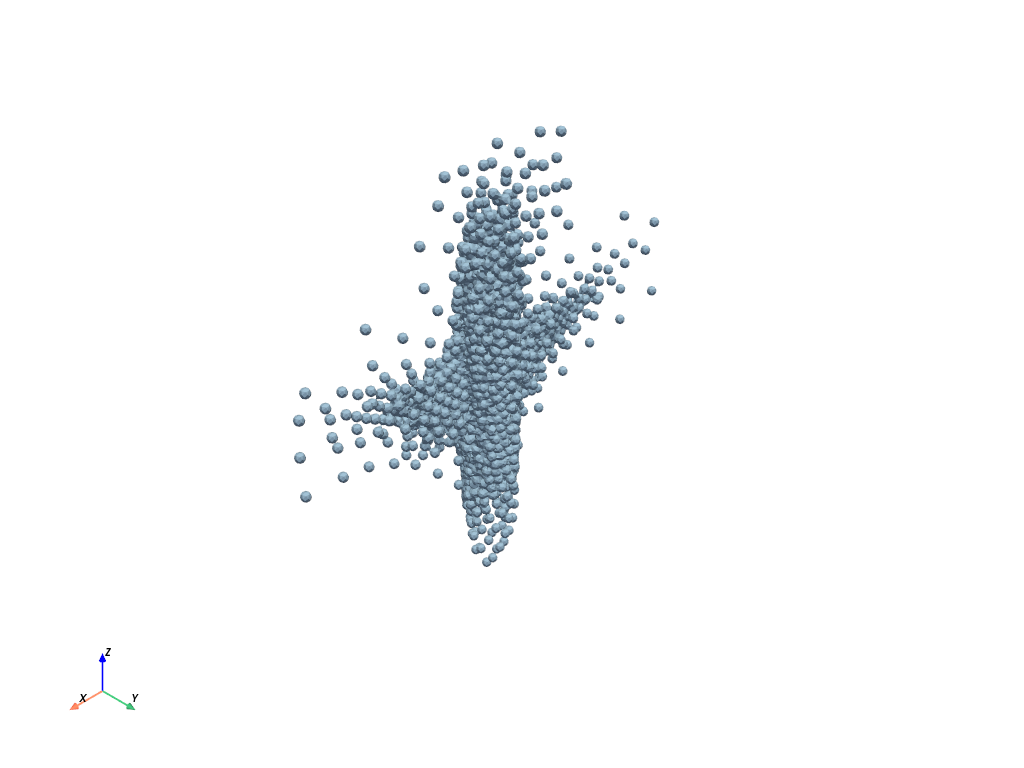

In [ ]:
import numpy as np
import open3d as o3d
import pyvista as pv

points = np.load("test_prediction.npy")
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

sphere_radius = 0.02  # adjust based on your model size
spheres = []

for pt in points:
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=sphere_radius)
    sphere.translate(pt)
    spheres.append(sphere)

merged_mesh = spheres[0]
for s in spheres[1:]:
    merged_mesh += s  # combine meshes

merged_mesh.merge_close_vertices(0.01)  # tolerance, adjust as needed
merged_mesh.compute_vertex_normals()

vertices = np.asarray(merged_mesh.vertices)
faces = np.asarray(merged_mesh.triangles)
faces_flat = np.hstack([np.full((faces.shape[0], 1), 3), faces]).flatten()
pv_mesh = pv.PolyData(vertices, faces_flat)
pv_mesh = pv_mesh.smooth(n_iter=10)
pv_mesh["colors"] = np.tile([180, 220, 255], (pv_mesh.n_points, 1))  # light blue
pv_mesh.plot(notebook=True, scalars="colors", rgb=True, show_edges=False)
